CV Kaggle #2

Филаменты — это более холодные, темные облака газа над поверхностью Солнца.

In [1]:
import random, numpy as np, torch
random.seed(42); np.random.seed(42); torch.manual_seed(42)

Unarchive data files

In [4]:
import zipfile

zip_file_path = r'X:\Desktop\kaggle\solar_project_cv\filament-segmentation-2026.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall()

In [2]:
from collections import Counter
import os
import cv2
import json

In [3]:
train_img_dir = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images"
train_lbl_file = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train.json"

In [4]:
img_shapes = []
label_counts = Counter()
missing_images =[]
bad_labels = []

with open(train_lbl_file, "r") as f:
    data = json.load(f)

for img_info in data.get("images", []):
    img_file = img_info["file_name"]
    img_path = os.path.join(train_img_dir, img_file)

    if not os.path.exists(img_path):
        missing_images.append(img_file)
        continue
    w = img_info.get("width")
    h = img_info.get("height")
    img_shapes.append((w,h))


for ann in data.get("annotations", []):
    cat_id = ann.get("category_id")
    if cat_id is not None:
        label_counts[cat_id] += 1 

    else:
        bad_labels.append(ann)

print(f"Total processed images: {len(img_shapes)}")
print(f"Missing images on disk: {len(missing_images)}")
print(f"Label counts by category_id: {dict(label_counts)}")

Total processed images: 1154
Missing images on disk: 0
Label counts by category_id: {2: 2590, 3: 3074, 1: 2535}


In [5]:
len(img_shapes)

1154

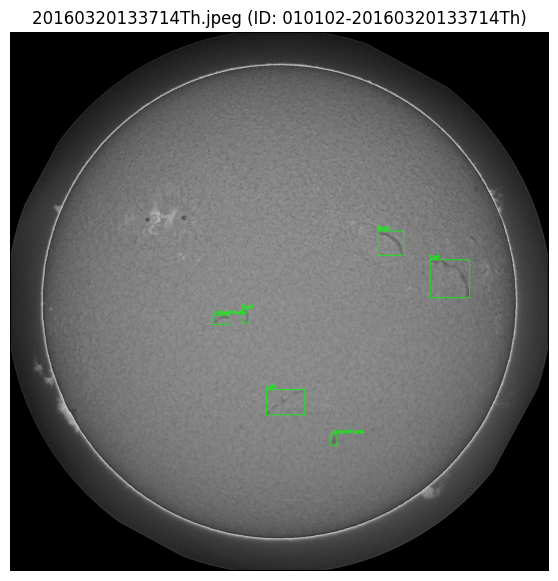

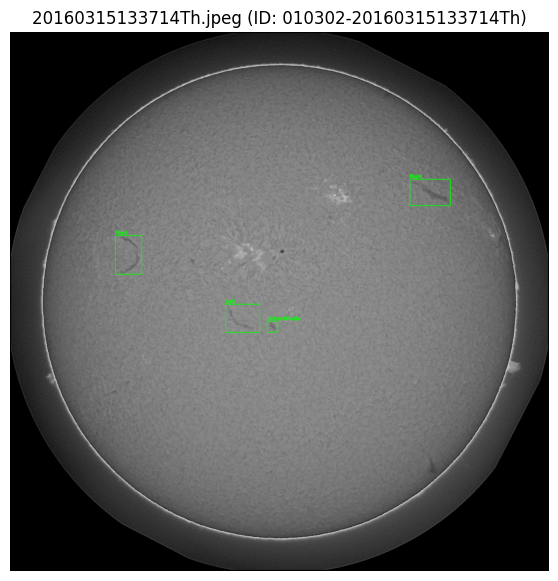

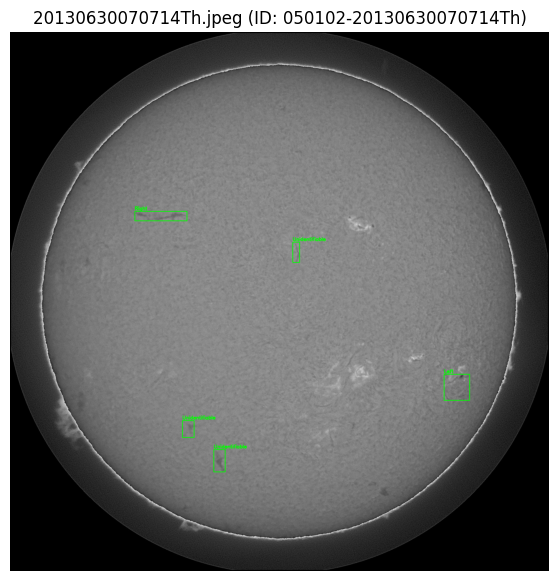

In [9]:
import random
import matplotlib.pyplot as plt

images_list = data.get("images", [])
categories_map = {cat['id']: cat['name'] for cat in data.get("categories", [])}

annotations_by_img_id = {}
for ann in data.get("annotations", []):
    img_id = ann["image_id"]
    annotations_by_img_id.setdefault(img_id, []).append(ann)

sample_images = random.sample(images_list, min(3, len(images_list)))

for img_info in sample_images:
    img_filename = img_info["file_name"]
    img_id = img_info["id"]
    img_path = os.path.join(train_img_dir, img_filename)

    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load image: {img_path}")
        continue
    anns = annotations_by_img_id.get(img_id, [])

    for ann in anns:

        x_min, y_min, bw, bh = ann["bbox"]
        cat_id = ann["category_id"]
        cat_name = categories_map.get(cat_id, str(cat_id))

        x1, y1 = int(x_min), int(y_min)
        x2, y2 = int(x_min+bw), int(y_min+bh)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            f"{cat_name}",
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{img_filename} (ID: {img_id})")
    plt.axis("off")
    plt.show()

In [5]:
images_list = data.get("images", [])
categories_map = {cat["id"]: cat["name"] for cat in data.get("categories", [])}

In [6]:
annotations_by_img_id = {}
for ann in data.get("annotations", []):
    img_id = ann["image_id"]
    annotations_by_img_id.setdefault(img_id, []).append(ann)

In [7]:
def display_images(images, indices):
    num_samples = len(indices)
    plt.figure(figsize=(15, 8), dpi=200)

    for i, img in enumerate(images):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()  # Исправлена опечатка (tight_layout)
    plt.show()

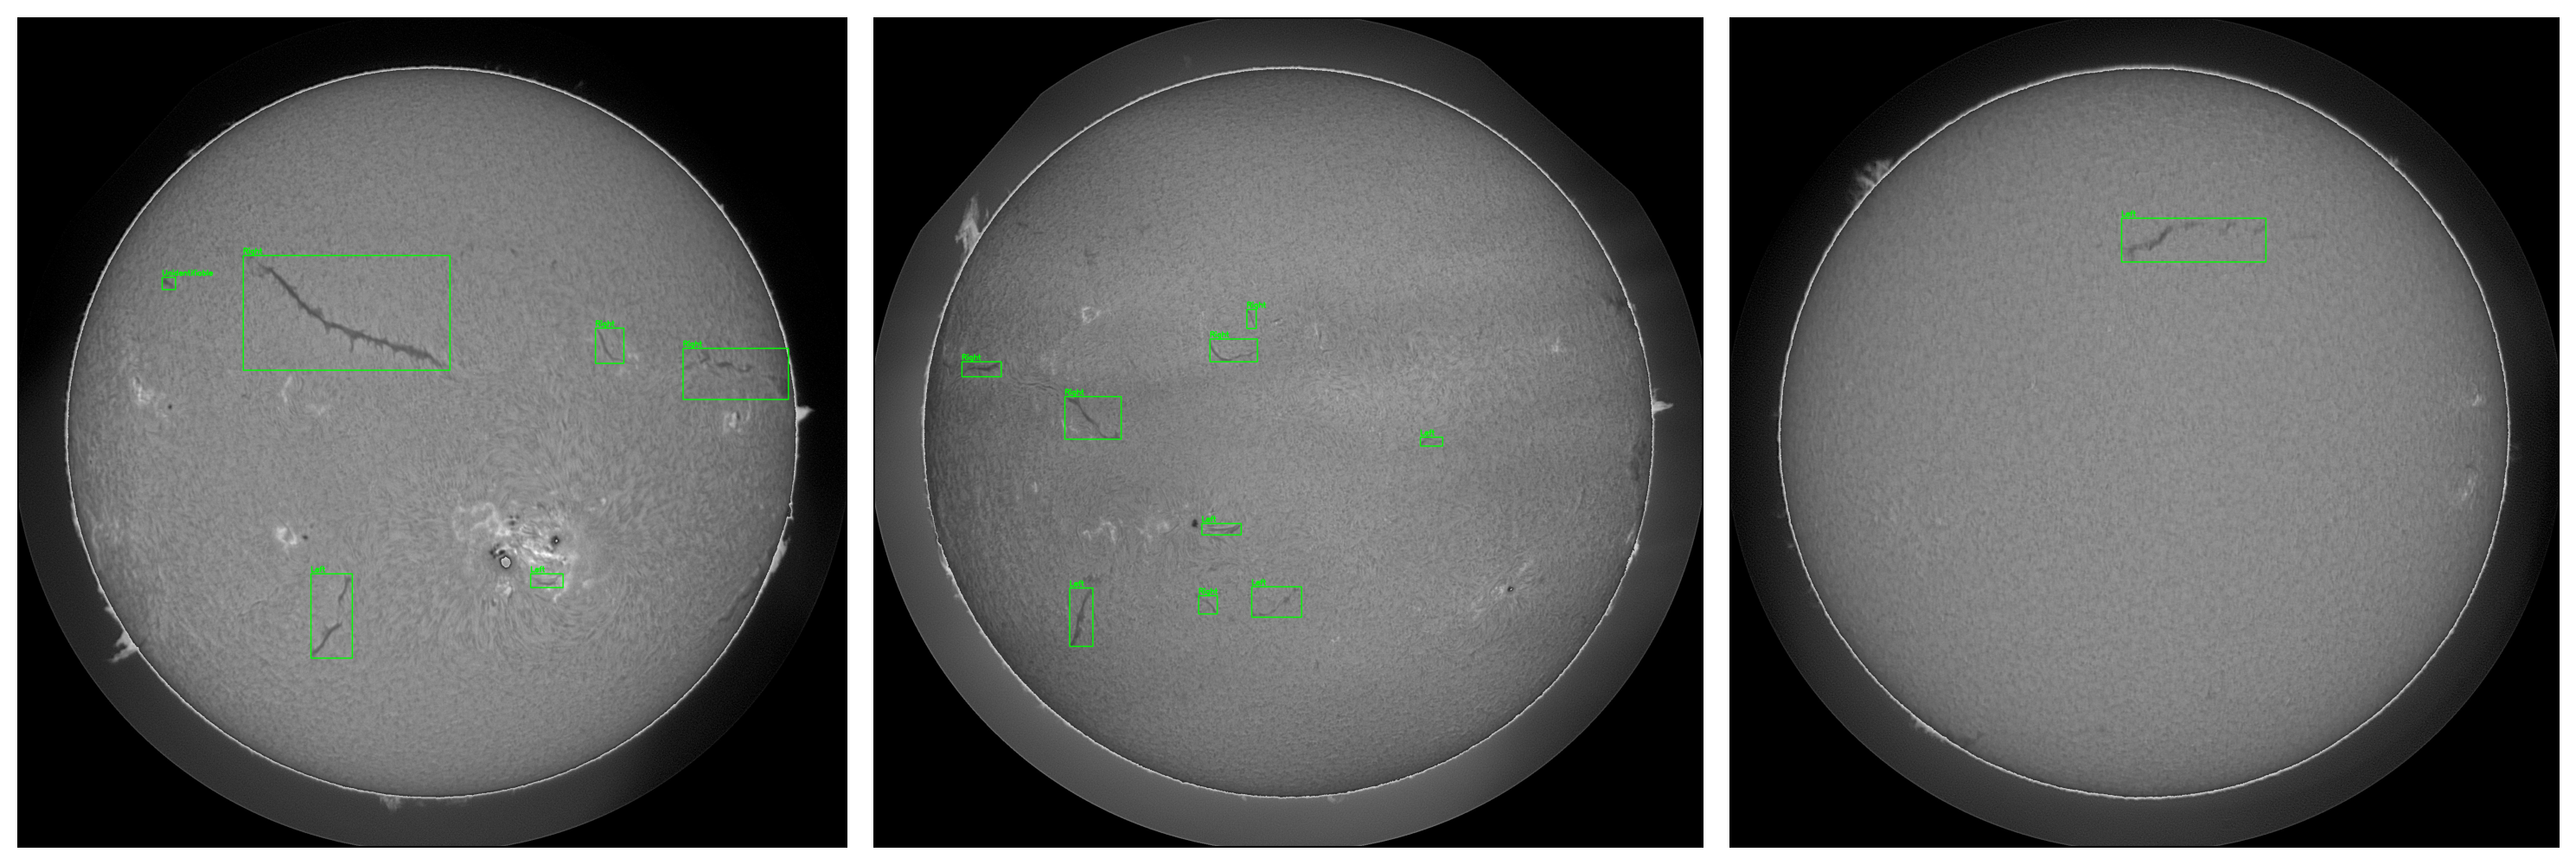

In [10]:
# 3. Выбор случайных индексов
sample_indices = np.random.choice(len(images_list), size=3, replace=False)
imgs = []

# 4. Загрузка картинок и наложение Bounding Box'ов
for i in sample_indices:
    img_info = images_list[i]
    img_filename = img_info["file_name"]
    img_id = img_info["id"]

    img_path = os.path.join(train_img_dir, img_filename)
    img = cv2.imread(img_path)

    if img is None:
        print(f"Не удалось загрузить: {img_path}")
        continue

    # Конвертируем из BGR в RGB для Matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Отрисовываем рамки
    anns = annotations_by_img_id.get(img_id, [])
    for ann in anns:
        x_min, y_min, bw, bh = ann["bbox"]
        cat_id = ann["category_id"]
        cat_name = categories_map.get(cat_id, str(cat_id))

        x1, y1 = int(x_min), int(y_min)
        x2, y2 = int(x_min + bw), int(y_min + bh)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            f"{cat_name}",
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )

    imgs.append(img)

# 5. Отображение
display_images(imgs, sample_indices)

Sample statistics

In [11]:
categories_map

{1: 'Left', 2: 'Right', 3: 'Unidentifiable', 4: 'Ambiguous'}

In [12]:
images = data.get("images", [])
annotations = data.get("annotations", [])

In [13]:
img_ann_count = Counter([ann["image_id"] for ann in annotations])
counts_per_img = [img_ann_count[img["id"]] for img in images]

print("=== 1. Filaments / Image ===")
print(f"Mean filaments/image: {np.mean(counts_per_img):.2f}")
print(f"Median: {np.median(counts_per_img):.1f}")
print(f"Max in single image: {np.max(counts_per_img)}")
print(f"Images with 0 filaments: {counts_per_img.count(0)}")

=== 1. Filaments / Image ===
Mean filaments/image: 7.10
Median: 7.0
Max in single image: 26
Images with 0 filaments: 0


In [14]:
areas = []
widths = []
heights = []
thin_filaments = 0

for ann in annotations:
    area = ann.get("area", 0)
    bbox = ann.get("bbox", [0, 0, 0, 0])  # [x, y, w, h]
    w, h = bbox[2], bbox[3]
    
    areas.append(area if area > 0 else w * h)
    widths.append(w)
    heights.append(h)
    
    # "Very thin" threshold: min(w, h) <= 5px or area < 100px
    if min(w, h) <= 5 or area < 100:
        thin_filaments += 1

print("\n=== 2 & 3. Filament Size & Thin Filaments ===")
print(f"Area Distribution (px): Min={np.min(areas):.0f}, Median={np.median(areas):.0f}, Max={np.max(areas):.0f}")
print(f"Very thin filaments (min side <= 5px or area < 100px): {thin_filaments} ({thin_filaments/len(annotations)*100:.1f}%)")


=== 2 & 3. Filament Size & Thin Filaments ===
Area Distribution (px): Min=9, Median=1228, Max=37739
Very thin filaments (min side <= 5px or area < 100px): 6 (0.1%)


In [27]:
type(areas)

list

In [17]:
print("\n=== Filament Size in percentiles ===")
print(f"Area Distribution (px) in percentiles: \
     \n P1={np.percentile(areas, 1):.0f},  \
     \n P5={np.percentile(areas, 5):.0f}, \
     \nP10={np.percentile(areas, 10):.0f}, \
     \n P25={np.percentile(areas, 25):.0f}, \
     \n P50={np.percentile(areas, 50):.0f}, \
     \n P75={np.percentile(areas, 75):.0f}, \
     \n P90={np.percentile(areas, 90):.0f}, \
     \n P95={np.percentile(areas, 95):.0f}, \
     \n P99={np.percentile(areas, 99):.0f}, ")



=== Filament Size in percentiles ===
Area Distribution (px) in percentiles:      
 P1=209,       
 P5=317,      
P10=410,      
 P25=670,      
 P50=1228,      
 P75=2438,      
 P90=4685,      
 P95=6947,      
 P99=13703, 


majority has 13k+ pixels, so Max=37739 in previous code was an outlier, we can make use of architectures with large receptive field like U-Net, U-Net++

the importance of checking size distribution helps to avoid choosing wrong architecture for training. For example current dataset has around 1228 pixels for 50% of images but majority is around 10 times larger. So we need to avoid scaling 2048x2048 to 640x640 for example. and it might result in squezing those 209 px images even smaller getting to lose important information.

In [18]:
# 6. Image Resolutions
resolutions = Counter([(img["width"], img["height"]) for img in images])
print("\n=== 6. Image Resolutions ===")
for res, count in resolutions.items():
    print(f"Resolution {res}: {count} images")


=== 6. Image Resolutions ===
Resolution (2048, 2048): 1154 images


In [19]:
import matplotlib.pyplot as plt
import pandas as pd

counts = [img_ann_count[img["id"]] for img in images]

bins = [0,1,4,7,10,13,21,float("inf")]
labels = ["0", "1-3", "4-6", "7-9", "10-12", "13-20", ">20"]

counts_cut = pd.cut(counts, bins=bins, labels=labels, right=False)
distribution = counts_cut.value_counts().sort_index()

total_imgs = len(images)
print("=== Number of instances per image distribution ===")
for label, count in distribution.items():
    percentage = (count / total_imgs) * 100
    print(f"  {label:<7} : {count:>5} images ({percentage:>5.1f}%)")

=== Number of instances per image distribution ===
  0       :     0 images (  0.0%)
  1-3     :   281 images ( 24.4%)
  4-6     :   267 images ( 23.1%)
  7-9     :   286 images ( 24.8%)
  10-12   :   187 images ( 16.2%)
  13-20   :   128 images ( 11.1%)
  >20     :     5 images (  0.4%)


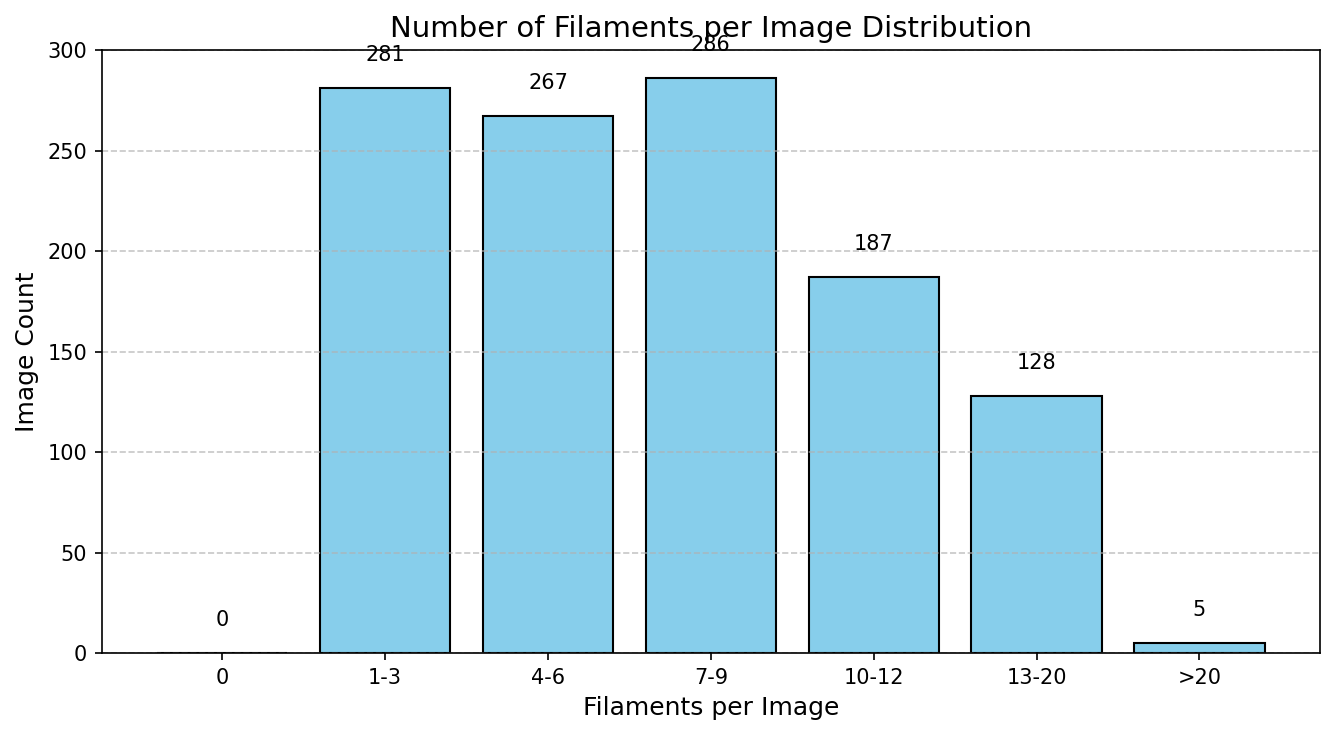

In [20]:
# Отрисовка гистограммы
plt.figure(figsize=(9, 5), dpi=150)
bars = plt.bar(
    distribution.index.astype(str),
    distribution.values,
    color="skyblue",
    edgecolor="black",
)
plt.title("Number of Filaments per Image Distribution", fontsize=14)
plt.xlabel("Filaments per Image", fontsize=12)
plt.ylabel("Image Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Добавляем значения над столбцами
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (total_imgs * 0.01),
        f"{yval}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.tight_layout()
plt.show()

##### Попарное сравнение бинарных масок на пиксельном уровне чтобы оценить перекрытие и касание объектов

 -  Exact Pixel Intersection (Overlap) Логическое И
 
 -  Touching check (dilating mask_i by 1px to see if it meets mask_j) Морфологическая Дилатация (Расширение)
  Как? : маска `i` расширяется наружу на 1 пиксель во все стороны с помощью ядра **3x3** `cv2.dilate`
  накладывается логическое `И`
  Условие `not np.any(intersection)` гарантирует что мы фиксируем чистое касание на 1-2 пикселя а не прямое наложение

In [ ]:
from tqdm import tqdm

images_with_touches = 0
images_with_overlaps = 0
total_touching_pairs = 0
total_overlapping_pairs = 0
total_evaluated_pairs = 0

ann
def seg_to_mask(seg, height, width):
    #convert COCO polygon segmentation into binary mask

    mask = np.zeros((height, width), dtype=np.uint8)
    if isinstance(seg, list):
        for poly in seg:
            pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
            cv2.fillPoly(mask, [pts], 1)
    return mask

print("Analyzing touching and overlapping instances across images...")

for img_info in tqdm(images):
    img_id = img_info["id"]
    h, w = img_info["height"], img_info["width"]
    anns = annotations_by_img_id.get(img_id, [])

    if len(anns) < 2:
        continue  # Need at least 2 objects to touch or overlap

    # Render masks for all annotations in this image
    masks = [seg_to_mask(ann["segmentation"], h, w) for ann in anns]

    has_touch = False
    has_overlap = False

    # Pairwise comparison
    num_anns = len(anns)
    for i in range(num_anns):
        for j in range(i + 1, num_anns):
            total_evaluated_pairs += 1
            
            # 1. Exact Pixel Intersection (Overlap)
            intersection = np.logical_and(masks[i], masks[j])
            if np.any(intersection):
                has_overlap = True
                total_overlapping_pairs += 1

            # 2. Touching check (dilating mask_i by 1px to see if it meets mask_j)
            kernel = np.ones((3, 3), np.uint8)
            dilated_i = cv2.dilate(masks[i], kernel, iterations=1)
            touch = np.logical_and(dilated_i, masks[j])

            if np.any(touch) and not np.any(intersection):
                has_touch = True
                total_touching_pairs += 1

    if has_touch:
        images_with_touches += 1
    if has_overlap:
        images_with_overlaps += 1

print("\n=== 3. Touching / Overlapping Instances Summary ===")
print(
    f"Total images with >= 2 filaments: {sum(1 for anns in annotations_by_img_id.values() if len(anns) >= 2)}"
)
print(
    f"Images with OVERLAPPING masks (Pixel IoU > 0): {images_with_overlaps} ({(images_with_overlaps/total_imgs)*100:.1f}%)"
)
print(
    f"Images with TOUCHING masks (1-2px border boundary): {images_with_touches} ({(images_with_touches/total_imgs)*100:.1f}%)"
)
print(
    f"Total overlapping instance pairs: {total_overlapping_pairs} / {total_evaluated_pairs}"
)
print(
    f"Total touching instance pairs: {total_touching_pairs} / {total_evaluated_pairs}"
)

Analyzing touching and overlapping instances across images...


100%|██████████| 1154/1154 [05:15<00:00,  3.65it/s]


=== 3. Touching / Overlapping Instances Summary ===
Total images with >= 2 filaments: 1051
Images with OVERLAPPING masks (Pixel IoU > 0): 7 (0.6%)
Images with TOUCHING masks (1-2px border boundary): 8 (0.7%)
Total overlapping instance pairs: 7 / 36064
Total touching instance pairs: 9 / 36064


Анализ геометрии масок

Всего валидных аннотаций для проверки: 8199


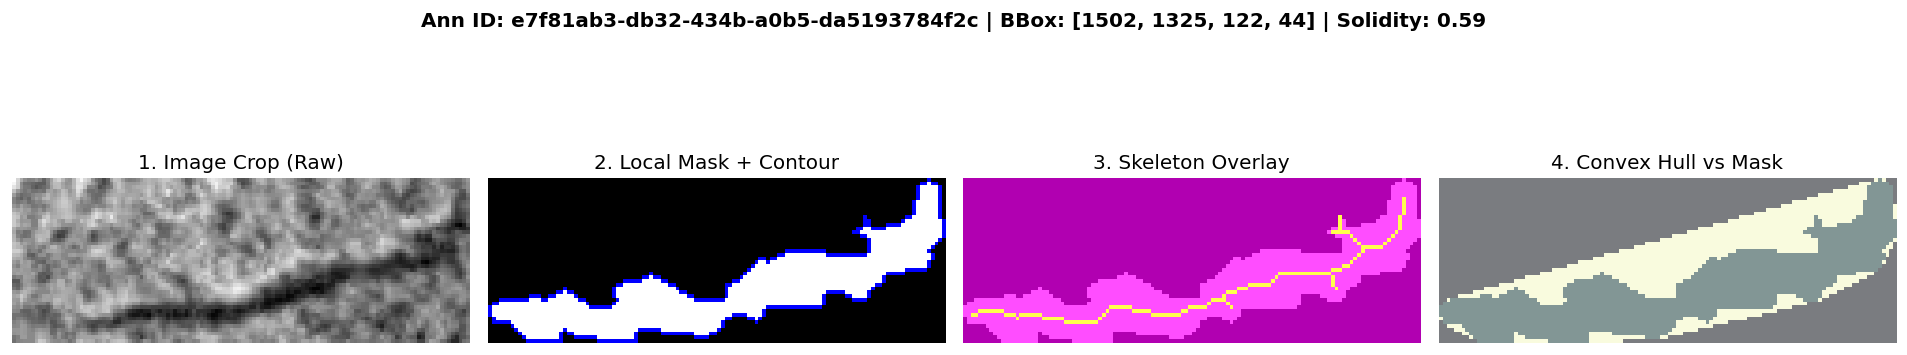

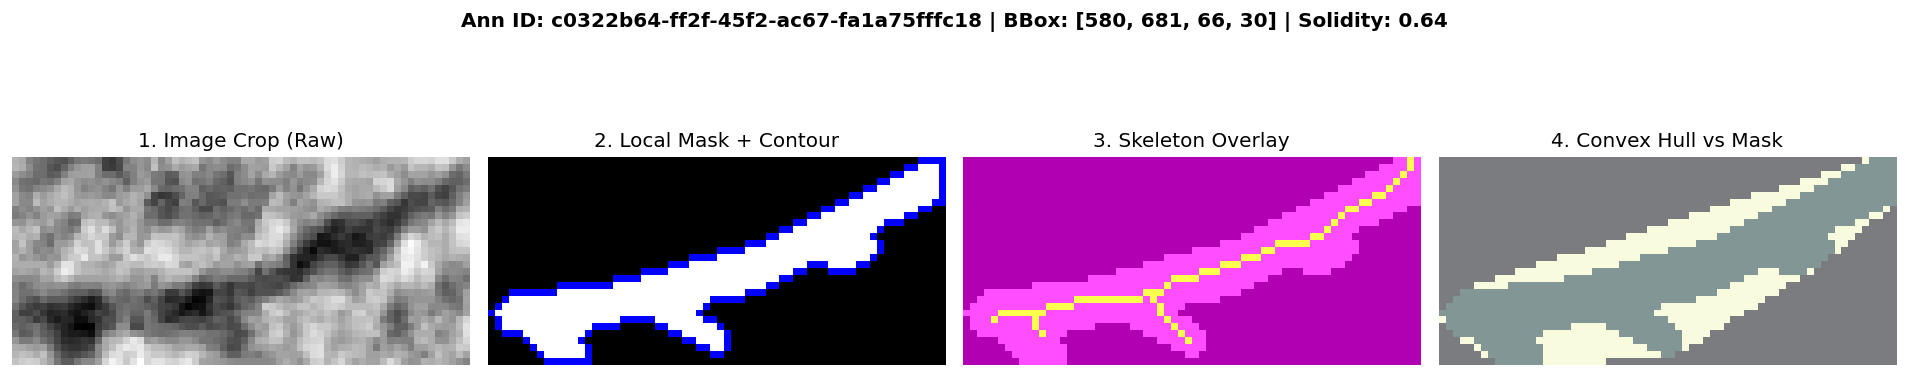

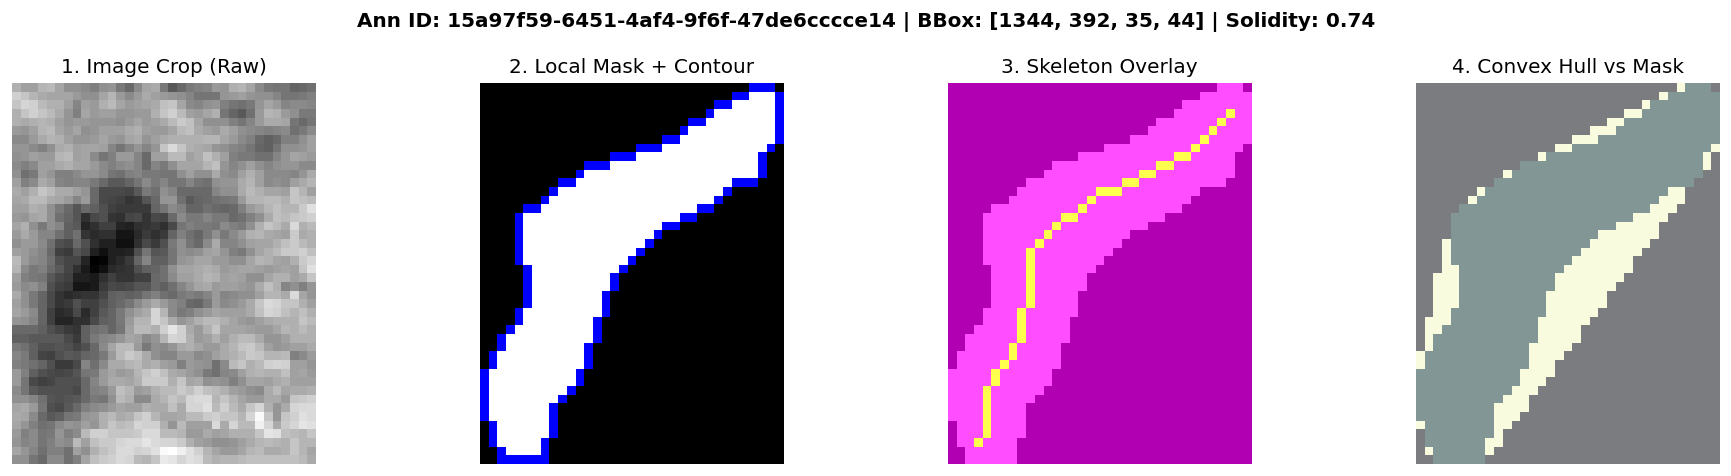

In [53]:
from skimage.morphology import convex_hull_image, skeletonize
# 1. Привязываем coco к data и строим словарь быстрого доступа
coco = data
images_map = {img["id"]: img for img in coco.get("images", [])}
annotations_list = coco.get("annotations", [])

# Фильтруем только те аннотации, у которых есть корректный BBox и существующая картинка
valid_anns = [
    a
    for a in annotations_list
    if a.get("bbox")
    and a.get("image_id") in images_map
    and a["bbox"][2] > 0
    and a["bbox"][3] > 0
]

print(f"Всего валидных аннотаций для проверки: {len(valid_anns)}")

# 2. Выбираем N случайных аннотаций
num_samples = 3
sample_anns = random.sample(valid_anns, min(num_samples, len(valid_anns)))

for ann in sample_anns:
    img_info = images_map[ann["image_id"]]

    # Загрузка кадра
    img_path = os.path.join(train_img_dir, img_info["file_name"])
    full_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if full_img is None:
        print(f"Ошибка загрузки файла: {img_path}")
        continue

    # Извлекаем BBox [x_min, y_min, width, height]
    bbox = ann["bbox"]
    x_min, y_min = int(bbox[0]), int(bbox[1])
    bw, bh = int(bbox[2]), int(bbox[3])
    x_max, y_max = x_min + bw, y_min + bh

    # Кроп изображения
    img_crop = full_img[y_min:y_max, x_min:x_max]

    # Создание локальной маски со сдвигом координат
    local_mask = np.zeros((bh, bw), dtype=np.uint8)
    for poly in ann.get("segmentation", []):
        pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
        pts[:, 0] -= x_min  # Сдвиг по X
        pts[:, 1] -= y_min  # Сдвиг по Y
        cv2.fillPoly(local_mask, [pts], 1)

    if np.sum(local_mask) == 0:
        continue

    # Расчет скелета и Convex Hull
    skel = skeletonize(local_mask > 0)
    hull = convex_hull_image(local_mask)

    # Отрисовка контуров
    contours, _ = cv2.findContours(
        local_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    mask_contours = cv2.cvtColor(
        (local_mask * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR
    )
    if contours:
        cv2.drawContours(mask_contours, contours, -1, (0, 0, 255), 1)

    # Метрика Solidity
    solidity_val = np.sum(local_mask) / np.sum(hull)

    # 3. Визуализация 4 панелей
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=120)
    fig.suptitle(
        f"Ann ID: {ann['id']} | BBox: [{x_min}, {y_min}, {bw}, {bh}] | Solidity: {solidity_val:.2f}",
        fontsize=12,
        fontweight="bold",
    )

    axes[0].imshow(img_crop, cmap="gray")
    axes[0].set_title("1. Image Crop (Raw)")
    axes[0].axis("off")

    axes[1].imshow(mask_contours)
    axes[1].set_title("2. Local Mask + Contour")
    axes[1].axis("off")

    axes[2].imshow(local_mask, cmap="gray")
    axes[2].imshow(skel, cmap="spring", alpha=0.7)
    axes[2].set_title("3. Skeleton Overlay")
    axes[2].axis("off")

    axes[3].imshow(hull, cmap="magma")
    axes[3].imshow(local_mask, cmap="Blues", alpha=0.5)
    axes[3].set_title("4. Convex Hull vs Mask")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

In [16]:
from skimage.morphology import skeletonize
from skimage.measure import regionprops
from tqdm.notebook import tqdm
import pandas as pd

stats_list = []

print("Extracting shape statistics for all filament instances...")
images_map = {img["id"]: img for img in data.get("images", [])}

for ann in tqdm(annotations):
    img_info = images_map.get(ann["image_id"])
    if not img_info:
        continue

    h, w = img_info["height"], img_info["width"]
    seg = ann.get("segmentation", [])
    bbox = ann.get("bbox", [0, 0, 0, 0])
    
    bw, bh = bbox[2], bbox[3]
    if bw <= 0 or bh <=0:
        continue

    x_min, y_min = int(bbox[0]), int(bbox[1])
    x_max, y_max = int(x_min + bw), int(y_min + bh)

    crop_h, crop_w = max(1, y_max - y_min), max(1, x_max - x_min)
    local_mask = np.zeros((crop_h, crop_w), dtype=np.uint8)

    if isinstance(seg, list):
        for poly in seg:
            pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
            pts[:, 0] -= x_min
            pts[:, 1] -= y_min
            cv2.fillPoly(local_mask, [pts], 1)
    area = np.sum(local_mask)
    if area == 0:
        continue

    aspect_ratio = float(bw) / float(bh) if bh > 0 else 0

    contours, _ = cv2.findContours(
        local_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    perimeter = cv2.arcLength(contours[0], True) if contours else 0.0

    #Region properties(Solidity, Eccentricity, Extent)

    props = regionprops(local_mask)
    if props: 
        solidity = props[0].solidity
        eccentricity = props[0].eccentricity
        extent = props[0].extent
    else:
        solidity, eccentricity, extent = 0.0, 0.0, 0.0

    skel = skeletonize(local_mask > 0)
    skeleton_length = np.sum(skel)

    stats_list.append({
        "id" : ann.get("id"),
        "category_id" : ann.get("category_id"),
        "area" : area,
        "bbox_w" : bw,
        "bbox_h" : bh,
        "aspect_ratio":aspect_ratio,
        "perimeter":perimeter,
        'eccentricity':eccentricity,
        "solidity":solidity,
        "extent":extent,
        "skeleton_length":skeleton_length,
    })

df_shapes = pd.DataFrame(stats_list)


Extracting shape statistics for all filament instances...


  0%|          | 0/8199 [00:00<?, ?it/s]

In [54]:
df_shapes.head()

,id,category_id,area,bbox_w,bbox_h,aspect_ratio,perimeter,eccentricity,solidity,extent,skeleton_length
0,d7fd9cdb-3f34-4dfc-a1fa-c1fd25110a98,2,860,92.5264,52.4850,1.762911,267.320849,0.969609,0.460879,0.179766,107
1,ca65251f-f7c8-4553-ad55-ad0f06272782,3,1145,96.6123,46.1589,2.093037,260.735062,0.958710,0.424388,0.259284,94
2,7b301b5d-fe5d-4b4d-b0b7-41b0f8cabeec,1,1572,28.9432,145.3556,0.199120,392.918828,0.989140,0.439106,0.387192,167
3,184911bf-d671-4a08-bc84-6f5fb7ce5277,2,859,26.7045,96.0519,0.278022,248.267026,0.987470,0.631154,0.344151,119
4,67dcd25e-ed1e-4565-960e-d653c9a905ab,3,313,21.4859,40.8761,0.525635,106.325901,0.955813,0.698661,0.372619,44


In [48]:
df_shapes.describe()

,category_id,area,bbox_w,bbox_h,aspect_ratio,perimeter,eccentricity,solidity,extent,skeleton_length
count,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000
mean,2.065740,2282.936456,103.219585,91.789589,1.382090,390.154968,0.952666,0.581965,0.305059,176.134041
std,0.824542,2860.378988,92.972721,72.047429,1.034747,318.488631,0.064214,0.180413,0.158020,158.260320
min,1.000000,6.000000,3.820000,3.466600,0.122449,6.828427,0.162465,0.104053,0.034525,3.000000
25%,1.000000,745.500000,46.384650,43.611900,0.658209,183.317278,0.947355,0.451990,0.182435,74.000000
50%,2.000000,1355.000000,74.522600,69.605200,1.111182,292.350286,0.974136,0.580776,0.273901,127.000000
75%,3.000000,2638.000000,126.209500,116.592050,1.790317,488.060963,0.987092,0.713323,0.402455,221.000000
max,3.000000,39145.000000,1067.313600,709.807400,12.781679,3047.478476,0.999104,1.000000,0.960317,1777.000000


Анализ минимального Solidity:
ID аннотации: bfed9608-8ed0-4bdb-850b-fce9f8ae5a84
Значение Solidity: 1.0000


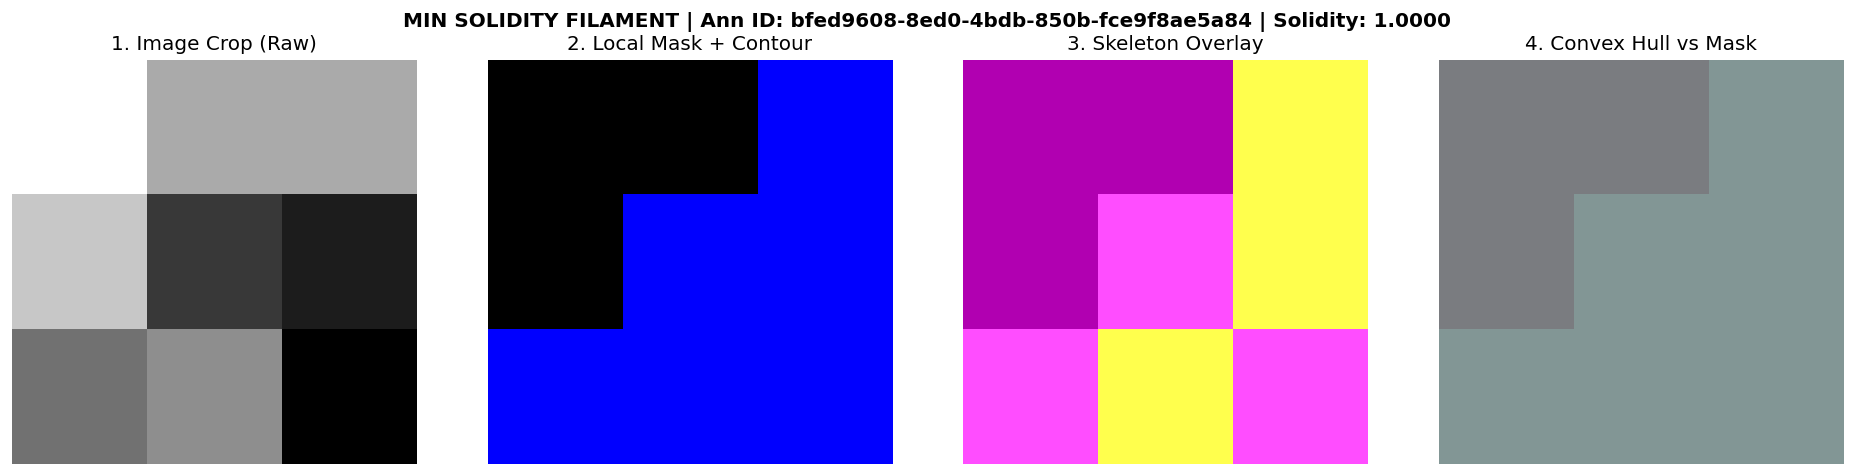

In [56]:
# 1. Находим запись с минимальным solidity в df_shapes
min_solidity_row = df_shapes.loc[df_shapes["solidity"].idxmax()]
min_ann_id = min_solidity_row["id"]
min_solidity_val = min_solidity_row["solidity"]

print(
    f"Анализ минимального Solidity:\nID аннотации: {min_ann_id}\nЗначение Solidity: {min_solidity_val:.4f}"
)

# 2. Находим исходную аннотацию в coco/data по ID
ann_target = next(
    (a for a in coco.get("annotations", []) if a.get("id") == min_ann_id), None
)
img_info = images_map.get(ann_target["image_id"]) if ann_target else None

if ann_target and img_info:
    # Загрузка кадра
    img_path = os.path.join(train_img_dir, img_info["file_name"])
    full_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # BBox и кроп
    bbox = ann_target["bbox"]
    x_min, y_min = int(bbox[0]), int(bbox[1])
    bw, bh = int(bbox[2]), int(bbox[3])

    img_crop = full_img[y_min : y_min + bh, x_min : x_min + bw]

    # Локальная маска
    local_mask = np.zeros((bh, bw), dtype=np.uint8)
    for poly in ann_target.get("segmentation", []):
        pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
        pts[:, 0] -= x_min
        pts[:, 1] -= y_min
        cv2.fillPoly(local_mask, [pts], 1)

    # Морфология
    skel = skeletonize(local_mask > 0)
    hull = convex_hull_image(local_mask)

    # Контуры
    contours, _ = cv2.findContours(
        local_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    mask_contours = cv2.cvtColor(
        (local_mask * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR
    )
    if contours:
        cv2.drawContours(mask_contours, contours, -1, (0, 0, 255), 1)

    # Visualisation
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=120)
    fig.suptitle(
        f"MIN SOLIDITY FILAMENT | Ann ID: {min_ann_id} | Solidity: {min_solidity_val:.4f}",
        fontsize=12,
        fontweight="bold",
    )

    axes[0].imshow(img_crop, cmap="gray")
    axes[0].set_title("1. Image Crop (Raw)")
    axes[0].axis("off")

    axes[1].imshow(mask_contours)
    axes[1].set_title("2. Local Mask + Contour")
    axes[1].axis("off")

    axes[2].imshow(local_mask, cmap="gray")
    axes[2].imshow(skel, cmap="spring", alpha=0.7)
    axes[2].set_title("3. Skeleton Overlay")
    axes[2].axis("off")

    axes[3].imshow(hull, cmap="magma")
    axes[3].imshow(local_mask, cmap="Blues", alpha=0.5)
    axes[3].set_title("4. Convex Hull vs Mask")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Аннотация или изображение не найдены.")

Это filament с самым высоким solidity и судя по графику является артефактом которую должны в будущем исключить с помощью
Минимальный порог площади (min_area_threshold):
Необходимо удалять все связные компоненты с площадью менее 15–20 пикселей через cv2.connectedComponentsWithStats.

In [27]:
# Display summary statistics
print("\n=== Shape Statistics Summary (Percentiles) ===")
print(
    df_shapes[
        ["area", "aspect_ratio", "perimeter", "solidity", "skeleton_length"]
    ].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
)


=== Shape Statistics Summary (Percentiles) ===
               area  aspect_ratio    perimeter     solidity  skeleton_length
count   8199.000000   8199.000000  8199.000000  8199.000000      8199.000000
mean    2282.936456      1.382090   390.154968     0.581965       176.134041
std     2860.378988      1.034747   318.488631     0.180413       158.260320
min        6.000000      0.122449     6.828427     0.104053         3.000000
5%       354.000000      0.326772   105.625396     0.283909        37.000000
25%      745.500000      0.658209   183.317278     0.451990        74.000000
50%     1355.000000      1.111182   292.350286     0.580776       127.000000
75%     2638.000000      1.790317   488.060963     0.713323       221.000000
95%     7336.700000      3.340969  1026.576935     0.885719       487.100000
max    39145.000000     12.781679  3047.478476     1.000000      1777.000000


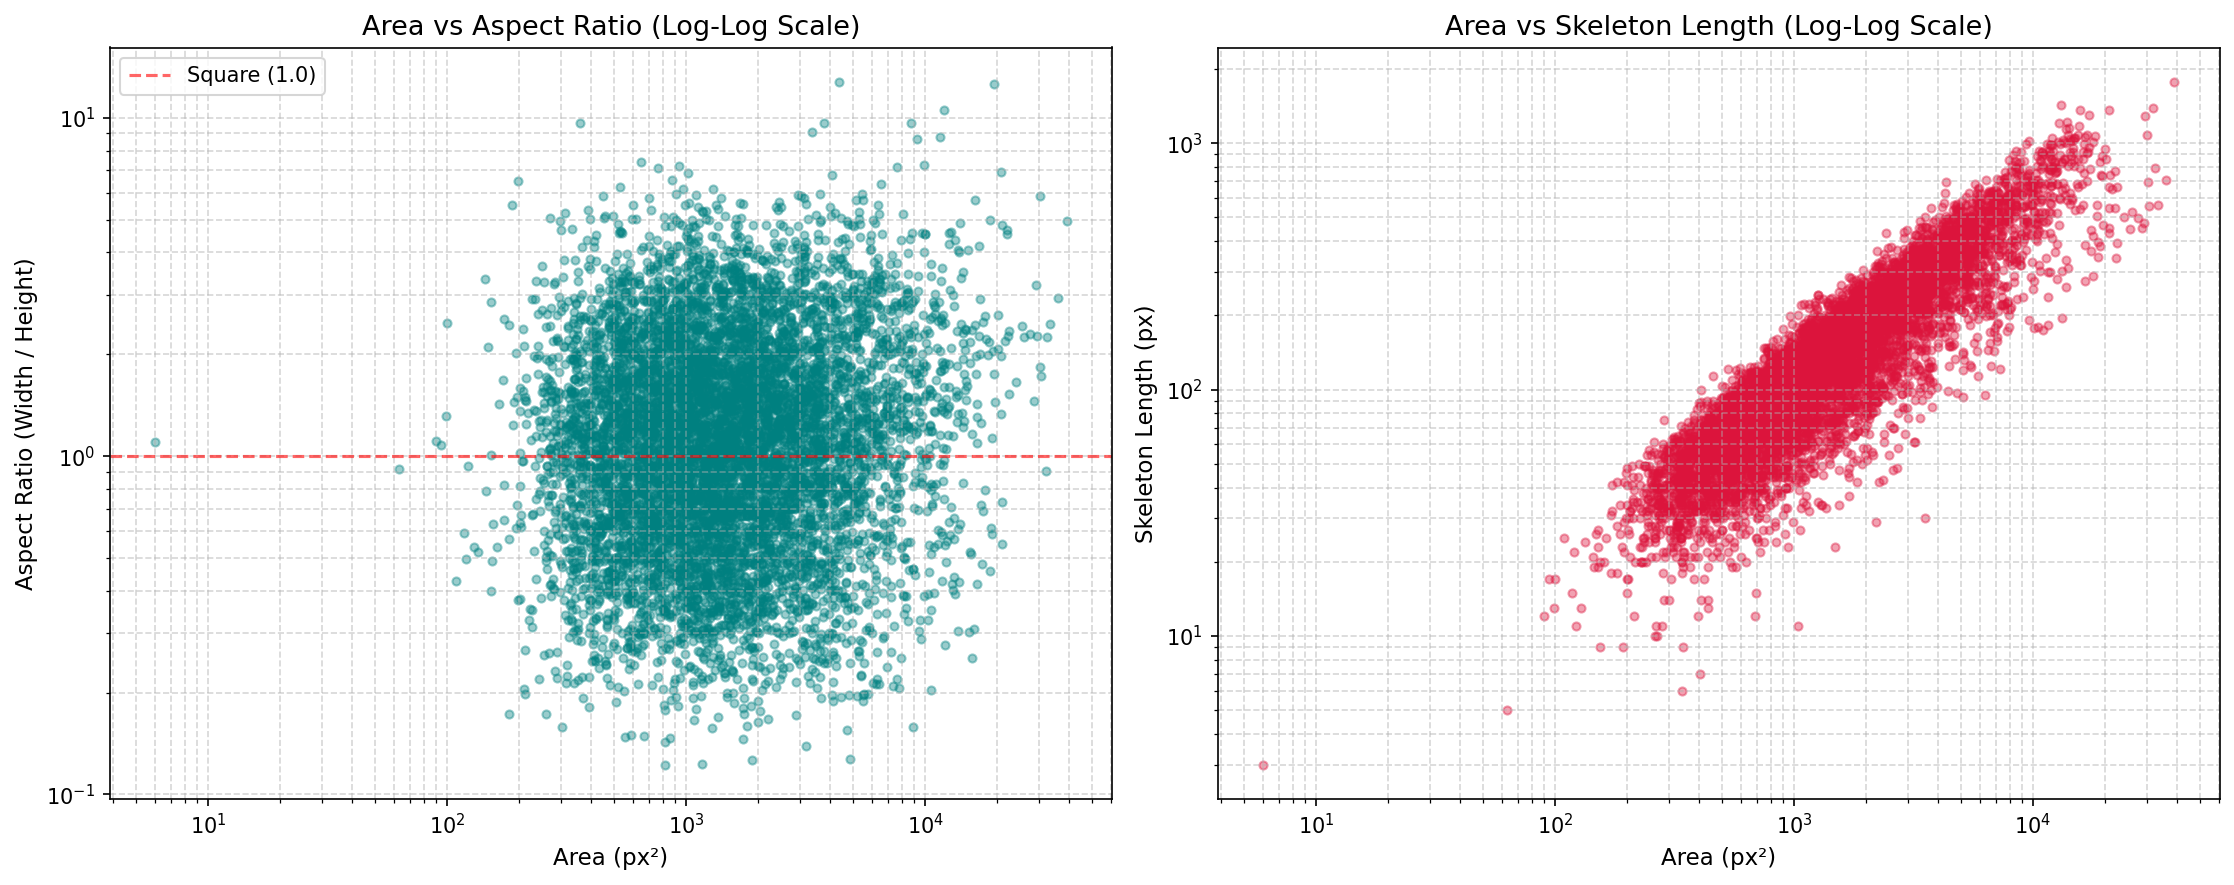

In [29]:
# -------------------------------------------------------------------
# Plot 1: Area vs Aspect Ratio & Plot 2: Area vs Skeleton Length
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)

# Plot 1: Area vs Aspect Ratio (Log scale on Area)
axes[0].scatter(
    df_shapes["area"], df_shapes["aspect_ratio"], alpha=0.4, c="teal", s=15
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Area vs Aspect Ratio (Log-Log Scale)", fontsize=13)
axes[0].set_xlabel("Area (px²)", fontsize=11)
axes[0].set_ylabel("Aspect Ratio (Width / Height)", fontsize=11)
axes[0].axhline(1.0, color="red", linestyle="--", alpha=0.6, label="Square (1.0)")
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)
axes[0].legend()

# Plot 2: Area vs Skeleton Length (Log scale)
axes[1].scatter(
    df_shapes["area"], df_shapes["skeleton_length"], alpha=0.4, c="crimson", s=15
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Area vs Skeleton Length (Log-Log Scale)", fontsize=13)
axes[1].set_xlabel("Area (px²)", fontsize=11)
axes[1].set_ylabel("Skeleton Length (px)", fontsize=11)
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

в первом графике смотрим на форму облака - предположительно идеальный круг указывает на пропорцию распределния filament-ов вертикально и горизонтально вытянутых с равной вероятностью, сигнал был бы если облако растянут непропорционально ломая хаотичную рандомность

наблюдаем жесткую линейную корреляцию между площадью и длиной оси filament-ов

skeletons correlation gives a hint to detect future false positives by comparing the ratio between area and skeleton lengths.

следующий график ниже это процент покрытия снимка филаментами поможет для оценки дисбаланса классов на пиксельном уровне

=== 5. Filament Occupancy Summary (% of image) ===
count    1154.000000
mean        0.359085
std         0.276886
min         0.006628
1%          0.015403
5%          0.035162
25%         0.135100
50%         0.302124
75%         0.530541
95%         0.853682
99%         1.236392
max         1.669359
Name: occupancy_pct, dtype: float64


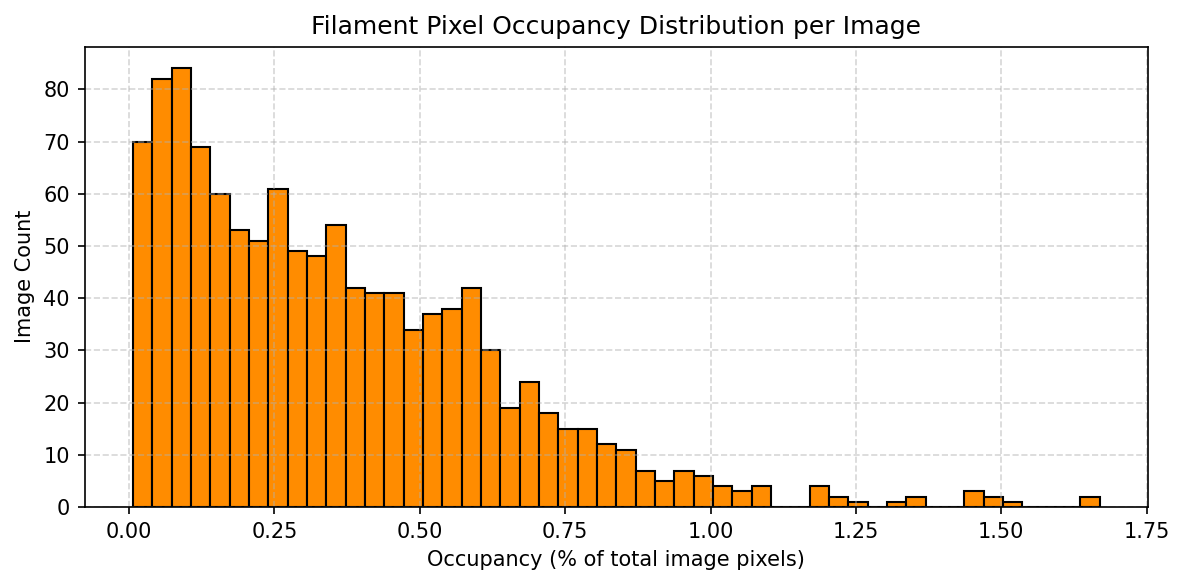

In [30]:
# Map area sums by image_id
img_area_sums = {img["id"]: 0.0 for img in images}
for ann in annotations:
    img_id = ann["image_id"]
    if img_id in img_area_sums:
        img_area_sums[img_id] += ann.get("area", 0.0)

# Calculate occupancy per image
occupancy_data = []
for img in images:
    img_id = img["id"]
    total_pixels = img["width"] * img["height"]
    filament_pixels = img_area_sums[img_id]
    occupancy_pct = (filament_pixels / total_pixels) * 100

    occupancy_data.append(
        {
            "image_id": img_id,
            "total_pixels": total_pixels,
            "filament_pixels": filament_pixels,
            "occupancy_pct": occupancy_pct,
        }
    )

df_occ = pd.DataFrame(occupancy_data)

print("=== 5. Filament Occupancy Summary (% of image) ===")
print(
    df_occ["occupancy_pct"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

# Plotting occupancy distribution
plt.figure(figsize=(8, 4), dpi=150)
plt.hist(df_occ["occupancy_pct"], bins=50, color="darkorange", edgecolor="black")
plt.title("Filament Pixel Occupancy Distribution per Image", fontsize=12)
plt.xlabel("Occupancy (% of total image pixels)", fontsize=10)
plt.ylabel("Image Count", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

for 2048x2048 = 4,194,304 pixels only 0.30% mean is around only 12,600 filament pixels which is very low amount of foreground where other 4.18 millions of pixels on the background.

PROBLEM: If we use Binary CrossEntropy loss we get good results by mistakenly predicting backgrounds.

Tip: use BCE+Dice or BCE+Tversky or Focal+Dice

еще это указывает из за того что объекты занимают меньшую область всего изображения при cropping важно центрировать вокруг уже существующей аннотации (в фильтр всегда попадают филаменты чтобы не брать полностью пустые без филаментов квадраты с фоном)

Следующее ниже это Фотометрический Анализ Яркости

Нужно было узнать насколько филаменты темнее чем окружающий фон - если да то могли бы использовать обычный OTSU Thresholding отделяя с пороговой бинаризацией

In [31]:
all_bg_pixels = []
all_fg_pixels =[]
all_img_pixels =[]

sample_size = min(100, len(images))
sampled_images = np.random.choice(images, size=sample_size, replace = False)

print(f"Sampling intensity values from {sample_size} solar images...")

for img_info in tqdm(sampled_images):
    img_path = os.path.join(train_img_dir, img_info["file_name"])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    h, w = img.shape
    fg_mask = np.zeros((h, w), dtype=np.uint8)

    anns = annotations_by_img_id.get(img_info["id"], [])

    for ann in anns:
        seg = ann.get("segmentation", [])
        if isinstance(seg, list):
            for poly in seg:
                pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
                cv2.fillPoly(fg_mask, [pts], 1)

    fg_pixels = img[fg_mask == 1]
    bg_pixels = img[fg_mask == 0]

    if len(fg_pixels)>0:
        all_fg_pixels.extend(fg_pixels[::2]) #sample every 2nd px
    all_bg_pixels.extend(bg_pixels[::100])
    all_img_pixels.extend(img.ravel()[::100])

all_fg = np.array(all_fg_pixels)
all_bg = np.array(all_bg_pixels)
all_img = np.array(all_img_pixels)

def get_stats(arr, name):
    return {
        "Region":name, 
        "Mean":np.mean(arr),
        "Std": np.std(arr),
        "P1": np.percentile(arr, 1),
        "P5": np.percentile(arr, 5),
        "P50 (Median)": np.percentile(arr, 50),
        "P95": np.percentile(arr, 95),
        "P99": np.percentile(arr, 99),
    }

# Build Summary DataFrame
df_stats = pd.DataFrame(
    [
        get_stats(all_img, "Full Image"),
        get_stats(all_bg, "Background Pixels"),
        get_stats(all_fg, "Filament Pixels (GT)"),
    ]
)

print("\n=== Intensity Distribution Statistics (0-255 Scale) ===")
print(df_stats.to_string(index=False))

Sampling intensity values from 100 solar images...


  0%|          | 0/100 [00:00<?, ?it/s]


=== Intensity Distribution Statistics (0-255 Scale) ===
              Region       Mean       Std   P1   P5  P50 (Median)   P95   P99
          Full Image  83.467705 56.658649  0.0  0.0         111.0 144.0 154.0
   Background Pixels  83.386413 56.727188  0.0  0.0         111.0 144.0 154.0
Filament Pixels (GT) 117.798651 15.094332 81.0 92.0         119.0 141.0 150.0


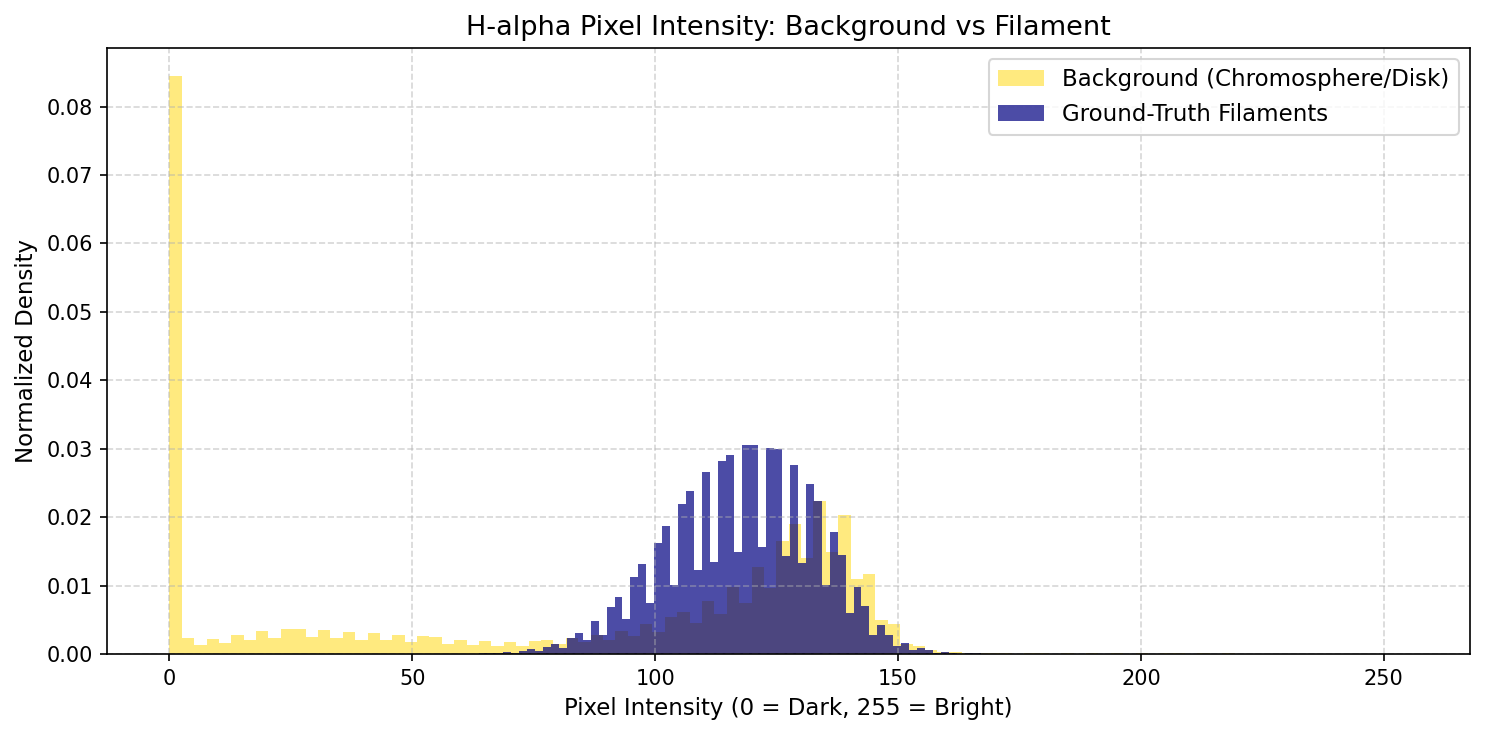

In [32]:
# -------------------------------------------------------------------
# Plotting Overlapping Intensity Distributions
# -------------------------------------------------------------------
plt.figure(figsize=(10, 5), dpi=150)

plt.hist(
    all_bg,
    bins=100,
    density=True,
    alpha=0.5,
    color="gold",
    label="Background (Chromosphere/Disk)",
)
plt.hist(
    all_fg,
    bins=100,
    density=True,
    alpha=0.7,
    color="navy",
    label="Ground-Truth Filaments",
)

plt.title("H-alpha Pixel Intensity: Background vs Filament", fontsize=13)
plt.xlabel("Pixel Intensity (0 = Dark, 255 = Bright)", fontsize=11)
plt.ylabel("Normalized Density", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

длинный бар у 0 указывает на черный космический вакуум за пределами солнечного диска

фиолетовой распределние филаментов полностью покрывает солнечное желтое распределние диска -> Canny edges здесь бессильны
Указывает на необходимость CLAHE - Adaptive Histogram Equalization

In [33]:
filament_metrics = []

print("Extracting per-filament metrics & local contrast...")

for ann in tqdm(annotations):
    img_info = images_map.get(ann["image_id"])
    if not img_info:
        continue

    img_path = os.path.join(train_img_dir, img_info["file_name"])
    if not os.path.exists(img_path):
        continue

    # Load crop region around the bounding box + padding
    bbox = ann.get("bbox", [0, 0, 0, 0])  # [x, y, w, h]
    bx, by, bw, bh = (
        int(bbox[0]),
        int(bbox[1]),
        int(bbox[2]),
        int(bbox[3]),
    )
    if bw <= 0 or bh <= 0:
        continue

    # Padding for local background ring sampling
    pad = 20
    img_h, img_w = img_info["height"], img_info["width"]
    x1, y1 = max(0, bx - pad), max(0, by - pad)
    x2, y2 = min(img_w, bx + bw + pad), min(img_h, by + bh + pad)

    img_full = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_full is None:
        continue
    crop_img = img_full[y1:y2, x1:x2]

    # Local binary mask
    crop_mask = np.zeros_like(crop_img, dtype=np.uint8)
    seg = ann.get("segmentation", [])
    if isinstance(seg, list):
        for poly in seg:
            pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
            pts[:, 0] -= x1
            pts[:, 1] -= y1
            cv2.fillPoly(crop_mask, [pts], 1)

    area = np.sum(crop_mask)
    if area == 0:
        continue

    # 1. Filament Intensity Stats
    fil_pixels = crop_img[crop_mask == 1]
    mean_int = np.mean(fil_pixels)
    std_int = np.std(fil_pixels)

    # 2. Local Background Sampling (Dilate mask by 10px and subtract inner mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    dilated_mask = cv2.dilate(crop_mask, kernel, iterations=1)
    bg_ring_mask = np.logical_and(dilated_mask == 1, crop_mask == 0)

    bg_pixels = crop_img[bg_ring_mask]
    mean_bg_int = np.mean(bg_pixels) if len(bg_pixels) > 0 else mean_int
    local_contrast = mean_bg_int - mean_int  # Higher = darker relative to local disk

    # 3. Shape properties
    props = regionprops(crop_mask)
    solidity = props[0].solidity if props else 0.0
    aspect_ratio = float(bw) / float(bh) if bh > 0 else 1.0

    # 4. Skeleton Length
    skel = skeletonize(crop_mask > 0)
    skel_len = np.sum(skel)

    filament_metrics.append(
        {
            "ann_id": ann["id"],
            "image_id": ann["image_id"],
            "file_name": img_info["file_name"],
            "area": area,
            "mean_intensity": mean_int,
            "std_intensity": std_int,
            "local_contrast": local_contrast,
            "solidity": solidity,
            "aspect_ratio": aspect_ratio,
            "skeleton_length": skel_len,
            "bbox": [bx, by, bw, bh],
        }
    )

df_fil = pd.DataFrame(filament_metrics)

# Normalized Composite Ease Score: High Area + High Contrast + High Solidity
df_fil["norm_area"] = (df_fil["area"] - df_fil["area"].min()) / (
    df_fil["area"].max() - df_fil["area"].min()
)
df_fil["norm_contrast"] = (
    df_fil["local_contrast"] - df_fil["local_contrast"].min()
) / (df_fil["local_contrast"].max() - df_fil["local_contrast"].min())
df_fil["ease_score"] = (
    0.4 * df_fil["norm_contrast"] + 0.3 * df_fil["norm_area"] + 0.3 * df_fil["solidity"]
)

easy_filaments = df_fil.sort_values("ease_score", ascending=False).head(5)
difficult_filaments = df_fil.sort_values("ease_score", ascending=True).head(5)

# Output Comparative Summary
print("\n=== EASY FILAMENTS (High Contrast, High Area, Clear Boundaries) ===")
print(
    easy_filaments[
        [
            "ann_id",
            "area",
            "mean_intensity",
            "local_contrast",
            "solidity",
            "skeleton_length",
        ]
    ].to_string(index=False)
)

print("\n=== DIFFICULT FILAMENTS (Low Contrast, Irregular/Small Structure) ===")
print(
    difficult_filaments[
        [
            "ann_id",
            "area",
            "mean_intensity",
            "local_contrast",
            "solidity",
            "skeleton_length",
        ]
    ].to_string(index=False)
)

Extracting per-filament metrics & local contrast...


  0%|          | 0/8199 [00:00<?, ?it/s]


=== EASY FILAMENTS (High Contrast, High Area, Clear Boundaries) ===
                              ann_id  area  mean_intensity  local_contrast  solidity  skeleton_length
84fa1caa-dfee-403e-9133-32400e74cfe6   280      133.207143       51.343761  0.649652               54
a1ebebd1-6020-4fe2-ac8a-2bb53dbdc970   354       94.737288       38.753254  0.813793               37
0515a787-83d9-492d-84df-edd80513eb61 32415      110.524819       15.175434  0.609912              795
9511b0e6-d171-49fb-aa30-e2de476a76ad 18714      106.245859       25.142494  0.678757              399
62d94cf9-0579-417f-bd0f-f33b0b7570a9 29431      108.152526       16.599651  0.596639             1287

=== DIFFICULT FILAMENTS (Low Contrast, Irregular/Small Structure) ===
                              ann_id  area  mean_intensity  local_contrast  solidity  skeleton_length
9e23b211-c549-48b8-94b3-76d0862e6e39  2685      123.138547        3.713175  0.151549              284
c1b1d82c-1c2f-4224-89b7-1af31fbddde8   831  

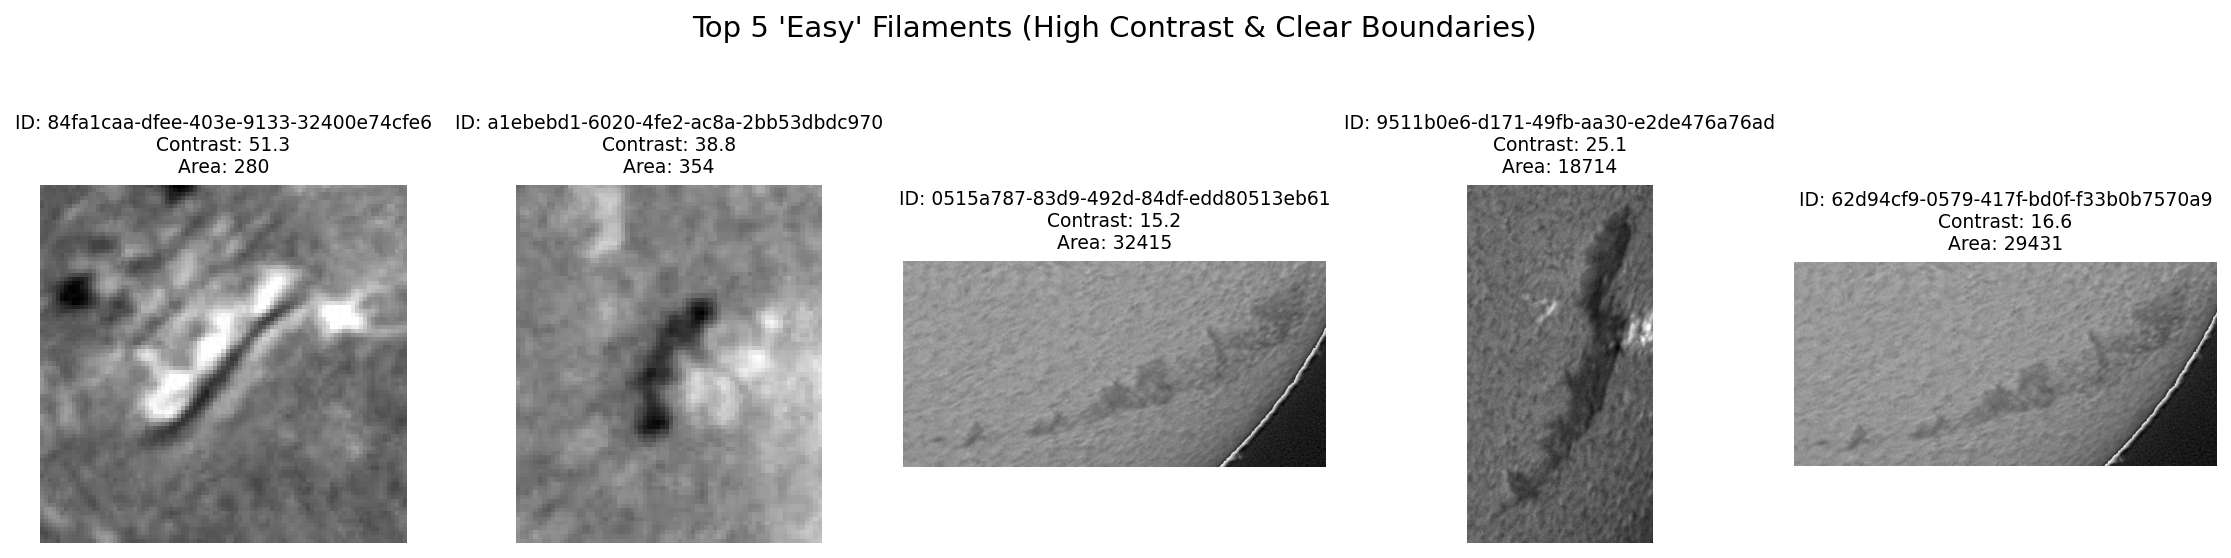

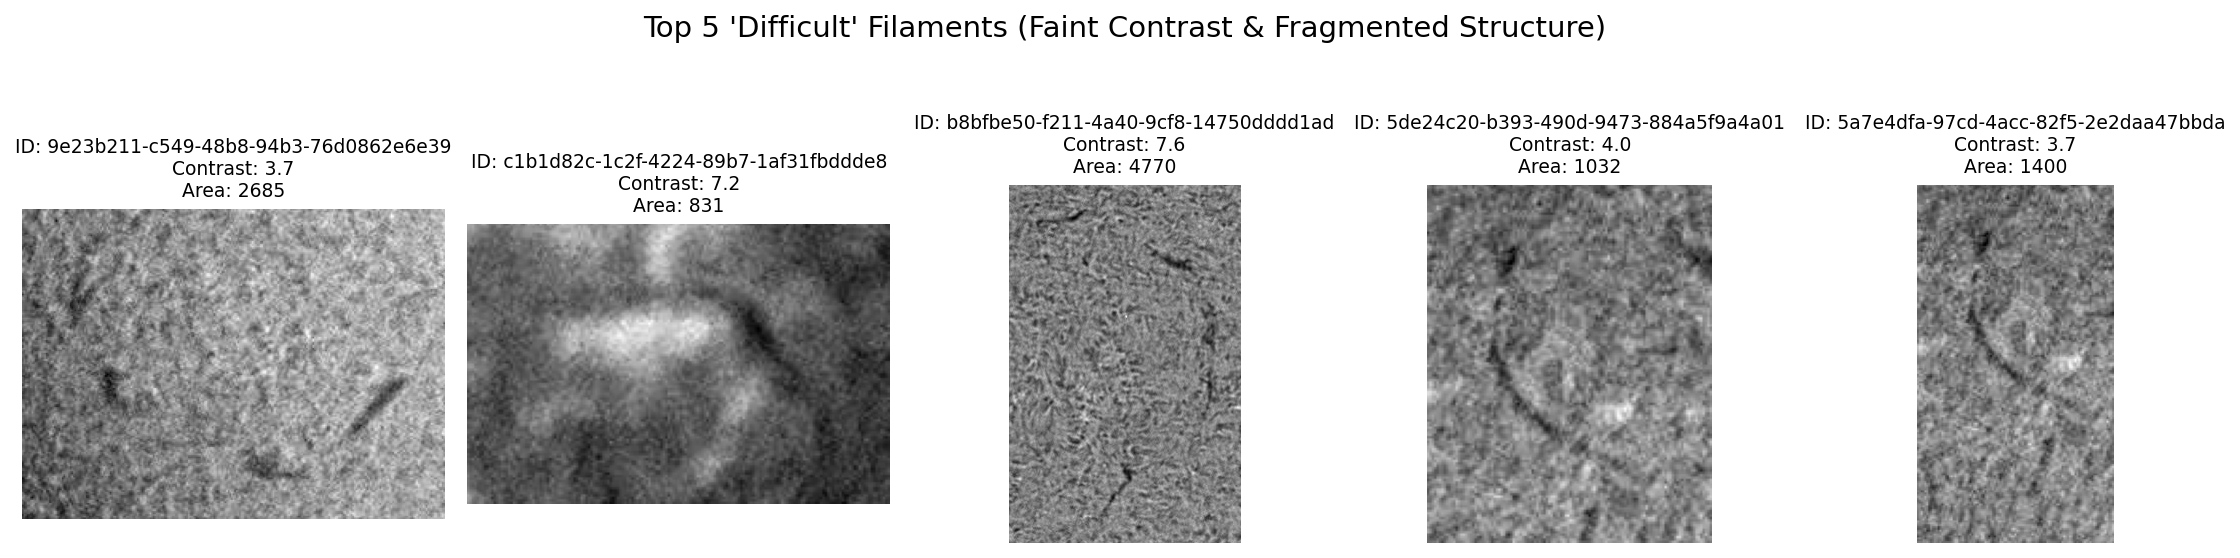

In [34]:
def plot_filament_samples(df_samples, title):
    fig, axes = plt.subplots(1, len(df_samples), figsize=(15, 3.5), dpi=150)
    fig.suptitle(title, fontsize=14, y=1.05)

    for idx, (_, row) in enumerate(df_samples.iterrows()):
        img_path = os.path.join(train_img_dir, row["file_name"])
        img_full = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        bx, by, bw, bh = row["bbox"]
        pad = 25
        x1, y1 = max(0, bx - pad), max(0, by - pad)
        x2, y2 = min(img_full.shape[1], bx + bw + pad), min(
            img_full.shape[0], by + bh + pad
        )

        crop = img_full[y1:y2, x1:x2]

        axes[idx].imshow(crop, cmap="gray")
        axes[idx].set_title(
            f"ID: {row['ann_id']}\nContrast: {row['local_contrast']:.1f}\nArea: {int(row['area'])}",
            fontsize=9,
        )
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()


plot_filament_samples(
    easy_filaments, "Top 5 'Easy' Filaments (High Contrast & Clear Boundaries)"
)
plot_filament_samples(
    difficult_filaments,
    "Top 5 'Difficult' Filaments (Faint Contrast & Fragmented Structure)",
)

In [35]:
import re
from datetime import datetime

timestamp_pattern = re.compile(r"(\d{14})")
parsed_images = []
for img in images:
    filename = img["file_name"]
    match = timestamp_pattern.search(filename)

    if match:
        dt_str = match.group(1)
        dt = datetime.strptime(dt_str, "%Y%m%d%H%M%S")
        date_day = dt.strftime("%Y-%m-%d")
        year_month = dt.strftime("%Y-%m")
    else:
        dt = None
        date_day = "Unknown"
        year_month="Unknown"

    parsed_images.append(
        {   
            "image_id":img["id"],
            "file_name":filename,
            "timestamp":dt,
            "date_day":date_day,
            "year_month":year_month,
        }
    )

df_time = pd.DataFrame(parsed_images)
df_time = df_time.sort_values("timestamp").reset_index(drop=True)

    # Calculate time deltas between consecutive observations
df_time["time_diff_min"] = (
    df_time["timestamp"].diff().dt.total_seconds() / 60.0
)

# Output Temporal Summary Statistics
print("=== Temporal Sampling & Correlation Leakage Summary ===")
print(f"Total Images: {len(df_time)}")
print(f"Unique Observation Days: {df_time['date_day'].nunique()}")
print(
    f"Date Range: {df_time['date_day'].min()} to {df_time['date_day'].max()}"
)
print(
    f"Median Time Between Sequential Frames: {df_time['time_diff_min'].median():.1f} minutes"
)
print(
    f"Frames captured < 15 mins apart: {(df_time['time_diff_min'] < 15).sum()} ({(df_time['time_diff_min'] < 15).mean()*100:.1f}%)"
)
        
        

=== Temporal Sampling & Correlation Leakage Summary ===
Total Images: 1154
Unique Observation Days: 656
Date Range: 2011-01-09 to 2022-08-03
Median Time Between Sequential Frames: 1440.0 minutes
Frames captured < 15 mins apart: 456 (39.5%)


In [ ]:
# Display sample of timestamps and close time intervals
print("\nSample Consecutive Timestamp Intervals:")
print(
    df_time[["file_name", "timestamp", "time_diff_min", "date_day"]]
    .head(10)
    .to_string()
)


Sample Consecutive Timestamp Intervals:
               file_name           timestamp  time_diff_min    date_day
0  20110109104734Ch.jpeg 2011-01-09 10:47:34            NaN  2011-01-09
1  20110114105034Ch.jpeg 2011-01-14 10:50:34    7203.000000  2011-01-14
2  20110114105034Ch.jpeg 2011-01-14 10:50:34       0.000000  2011-01-14
3  20110119082634Lh.jpeg 2011-01-19 08:26:34    7056.000000  2011-01-19
4  20110123174914Mh.jpeg 2011-01-23 17:49:14    6322.666667  2011-01-23
5  20110128174814Mh.jpeg 2011-01-28 17:48:14    7199.000000  2011-01-28
6  20110128174814Mh.jpeg 2011-01-28 17:48:14       0.000000  2011-01-28
7  20110128174814Mh.jpeg 2011-01-28 17:48:14       0.000000  2011-01-28
8  20110203082634Lh.jpeg 2011-02-03 08:26:34    8078.333333  2011-02-03
9  20110203082634Lh.jpeg 2011-02-03 08:26:34       0.000000  2011-02-03


Проверка тренировочных и тестовых наборов на **Covariate Shift**

Extracting image-level features from X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images...


  0%|          | 0/1154 [00:00<?, ?it/s]

Extracting image-level features from X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images...


  0%|          | 0/180 [00:00<?, ?it/s]

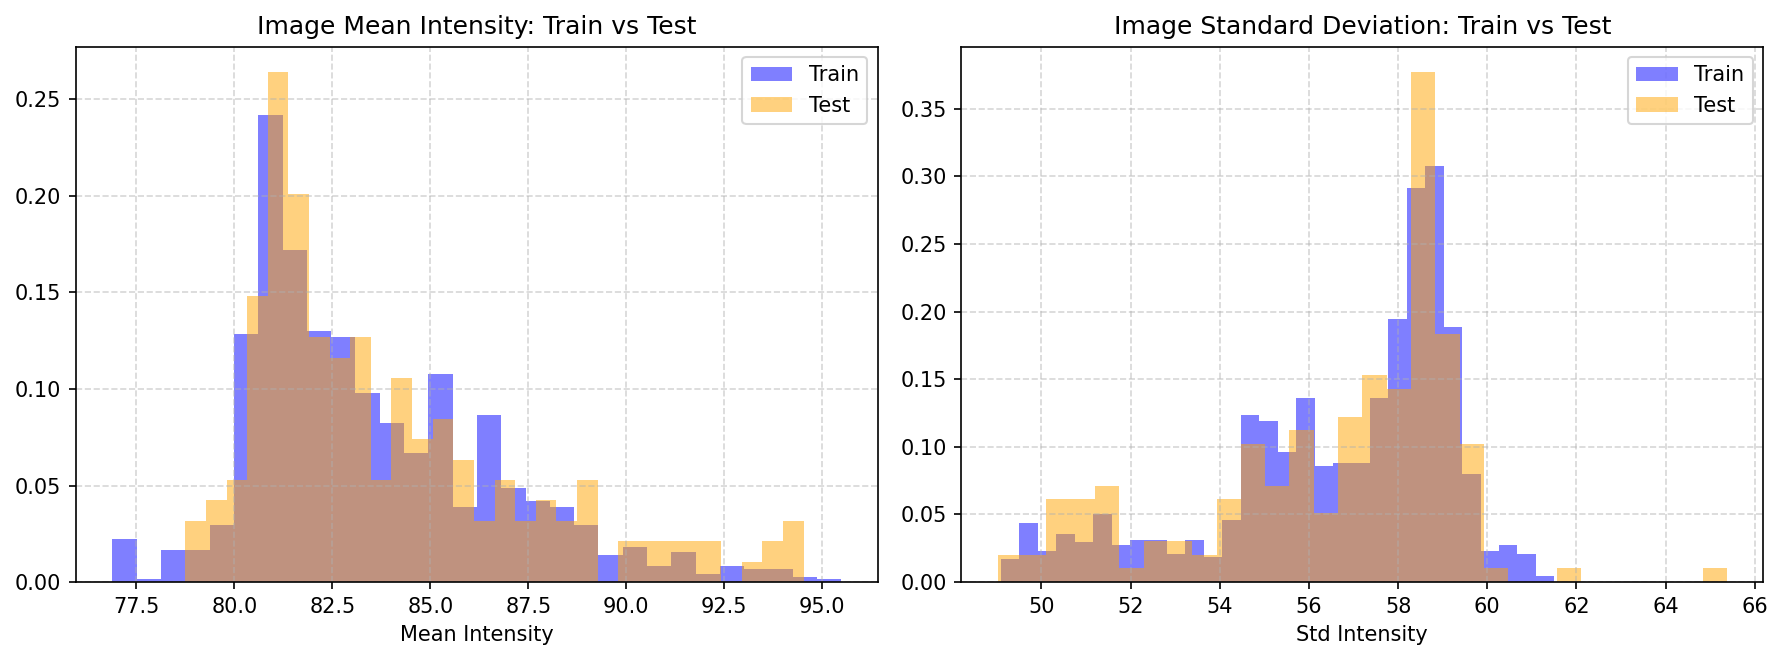


=== Adversarial Validation ROC-AUC Score: 0.559 ===
RESULT: Train and Test sets are identically distributed. No severe covariate shift detected!


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
test_img_dir = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"

# Load image metadata
with open(train_lbl_file, "r") as f:
    train_coco = json.load(f)

train_images = train_coco.get("images", [])
test_image_files = [
    f
    for f in os.listdir(test_img_dir)
    if f.lower().endswith((".jpeg"))
]


def extract_image_features(img_list, img_dir, is_coco=True):
    features = []
    print(f"Extracting image-level features from {img_dir}...")

    for item in tqdm(img_list):
        fname = item["file_name"] if is_coco else item
        img_path = os.path.join(img_dir, fname)

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Extract low-level image intensity features
        mean_val = np.mean(img)
        std_val = np.std(img)
        p1 = np.percentile(img, 1)
        p50 = np.percentile(img, 50)
        p99 = np.percentile(img, 99)

        features.append(
            {
                "file_name": fname,
                "width": img.shape[1],
                "height": img.shape[0],
                "mean": mean_val,
                "std": std_val,
                "p1": p1,
                "p50": p50,
                "p99": p99,
            }
        )

    return pd.DataFrame(features)


df_train_feats = extract_image_features(
    train_images, train_img_dir, is_coco=True
)
df_test_feats = extract_image_features(
    test_image_files, test_img_dir, is_coco=False
)

df_train_feats["is_test"] = 0
df_test_feats["is_test"] = 1

# 1. Compare Mean Intensity & Std Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)

axes[0].hist(
    df_train_feats["mean"],
    bins=30,
    alpha=0.5,
    label="Train",
    color="blue",
    density=True,
)
axes[0].hist(
    df_test_feats["mean"],
    bins=30,
    alpha=0.5,
    label="Test",
    color="orange",
    density=True,
)
axes[0].set_title("Image Mean Intensity: Train vs Test")
axes[0].set_xlabel("Mean Intensity")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].hist(
    df_train_feats["std"],
    bins=30,
    alpha=0.5,
    label="Train",
    color="blue",
    density=True,
)
axes[1].hist(
    df_test_feats["std"],
    bins=30,
    alpha=0.5,
    label="Test",
    color="orange",
    density=True,
)
axes[1].set_title("Image Standard Deviation: Train vs Test")
axes[1].set_xlabel("Std Intensity")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Adversarial Validation
df_combined = pd.concat(
    [df_train_feats, df_test_feats], ignore_index=True
).sample(frac=1, random_state=42)
X = df_combined[["width", "height", "mean", "std", "p1", "p50", "p99"]]
y = df_combined["is_test"]

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")

print(f"\n=== Adversarial Validation ROC-AUC Score: {np.mean(scores):.3f} ===")
if np.mean(scores) < 0.60:
    print(
        "RESULT: Train and Test sets are identically distributed. No severe covariate shift detected!"
    )
else:
    print(
        "WARNING: Significant distribution shift detected between Train and Test! Consider alignment/normalization."
    )

Если ROC-AUC $\approx 0.50$: Модель гадает случайным образом и не может отличить кадр из Train от кадра из Test. Это означает, что выборки идентичны по своим фотометрическим свойствам.Если ROC-AUC $> 0.60-0.70$: Модель легко находит разницу (например, если в Test изображения более темные или сняты на другой телескоп). Это предупреждает о сдвиге распределений (Covariate Shift).

In [38]:
import hashlib
timestamp_pattern = re.compile(r"(\d{14})")


def compute_md5(file_path, chunk_size=8192):
    """Compute MD5 hash of an image file to detect exact byte-for-byte duplicates."""
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()


file_records = []
print("Scanning dataset for file hashes and timestamp patterns...")

for img in tqdm(images):
    fname = img["file_name"]
    img_id = img["id"]
    img_path = os.path.join(train_img_dir, fname)

    # 1. Compute Hash
    img_hash = compute_md5(img_path) if os.path.exists(img_path) else None

    # 2. Extract Timestamp Prefix
    match = timestamp_pattern.search(fname)
    ts_str = match.group(1) if match else "Unknown"

    file_records.append(
        {
            "image_id": img_id,
            "file_name": fname,
            "md5_hash": img_hash,
            "timestamp_prefix": ts_str,
        }
    )

df_files = pd.DataFrame(file_records)

# -------------------------------------------------------------------
# 1. Identify Exact MD5 Hash Duplicates
# -------------------------------------------------------------------
hash_counts = df_files["md5_hash"].value_counts()
duplicate_hashes = hash_counts[hash_counts > 1].index

df_hash_dups = df_files[df_files["md5_hash"].isin(duplicate_hashes)].sort_values(
    "md5_hash"
)

# -------------------------------------------------------------------
# 2. Identify Matching Timestamp Duplicates
# -------------------------------------------------------------------
ts_counts = df_files["timestamp_prefix"].value_counts()
duplicate_timestamps = ts_counts[
    (ts_counts > 1) & (ts_counts.index != "Unknown")
].index

df_ts_dups = df_files[
    df_files["timestamp_prefix"].isin(duplicate_timestamps)
].sort_values("timestamp_prefix")

# -------------------------------------------------------------------
# Report Summary
# -------------------------------------------------------------------
print("\n=== DUPLICATE ANALYSIS SUMMARY ===")
print(f"Total Images Analyzed: {len(df_files)}")
print(
    f"Exact MD5 Byte-Level Duplicates: {len(df_hash_dups)} images ({len(duplicate_hashes)} unique groups)"
)
print(
    f"Identical Timestamp Prefixes: {len(df_ts_dups)} images ({len(duplicate_timestamps)} unique groups)"
)

if len(df_hash_dups) > 0:
    print("\nSample Exact MD5 Hash Duplicates:")
    print(df_hash_dups[["file_name", "md5_hash"]].head(6).to_string(index=False))

if len(df_ts_dups) > 0:
    print("\nSample Identical Timestamp Groups:")
    print(
        df_ts_dups[["file_name", "timestamp_prefix", "md5_hash"]]
        .head(6)
        .to_string(index=False)
    )

# -------------------------------------------------------------------
# Generate Unified Grouping ID for CV Splitting
# -------------------------------------------------------------------
# Combine timestamp_prefix and md5_hash so identical captures never cross folds
df_files["group_id"] = df_files["timestamp_prefix"].where(
    df_files["timestamp_prefix"] != "Unknown", df_files["md5_hash"]
)

df_files.to_csv("train_image_groups.csv", index=False)
print(
    "\n Saved 'group_id' mapping to 'train_image_groups.csv'. Use 'group_id' for GroupKFold!"
)

Scanning dataset for file hashes and timestamp patterns...


  0%|          | 0/1154 [00:00<?, ?it/s]


=== DUPLICATE ANALYSIS SUMMARY ===
Total Images Analyzed: 1154
Exact MD5 Byte-Level Duplicates: 743 images (296 unique groups)
Identical Timestamp Prefixes: 743 images (296 unique groups)

Sample Exact MD5 Hash Duplicates:
            file_name                         md5_hash
20130219063134Lh.jpeg 00e9ae576168b7040883afeb52b16871
20130219063134Lh.jpeg 00e9ae576168b7040883afeb52b16871
20140205180154Bh.jpeg 030b270a2ee6802e24a12f865c5cb349
20140205180154Bh.jpeg 030b270a2ee6802e24a12f865c5cb349
20140205180154Bh.jpeg 030b270a2ee6802e24a12f865c5cb349
20120910074014Th.jpeg 0312f2c15482d476962d02a451180bae

Sample Identical Timestamp Groups:
            file_name timestamp_prefix                         md5_hash
20110114105034Ch.jpeg   20110114105034 92d1625d8dd0ad23d23d06c536d30b89
20110114105034Ch.jpeg   20110114105034 92d1625d8dd0ad23d23d06c536d30b89
20110128174814Mh.jpeg   20110128174814 9d2d5b4010609e1a73a8356d64509e0d
20110128174814Mh.jpeg   20110128174814 9d2d5b4010609e1a73a8356d6450

Rendering visual duplicate comparisons...


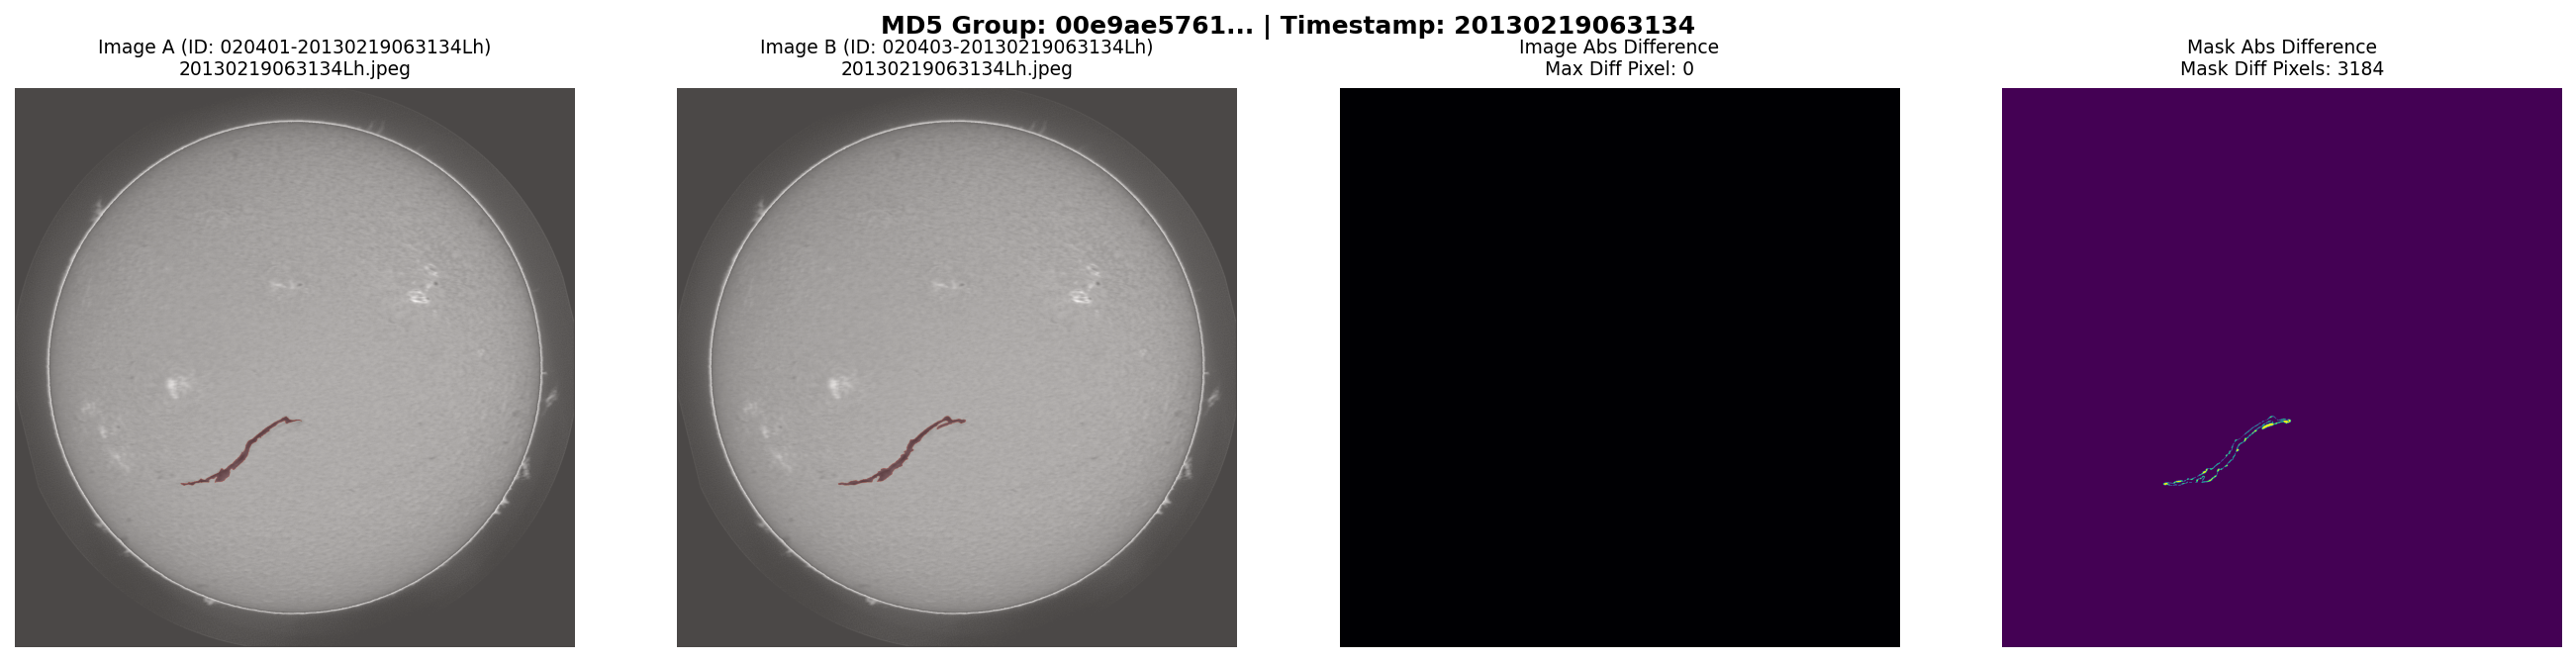

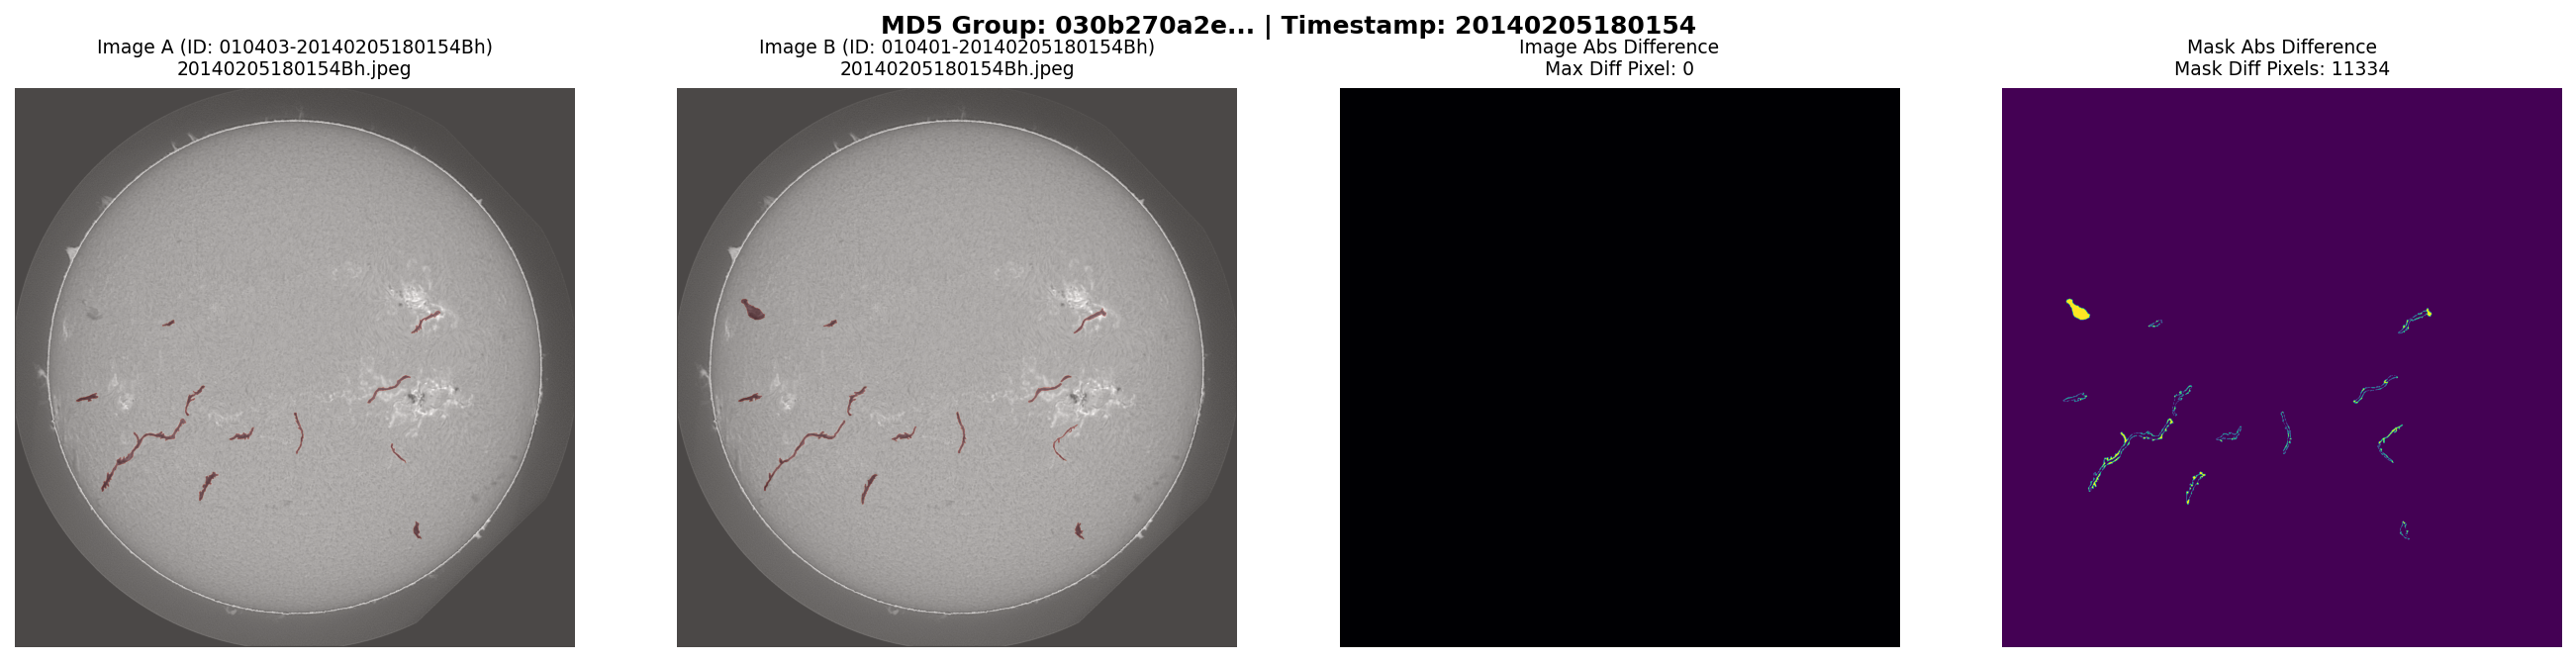

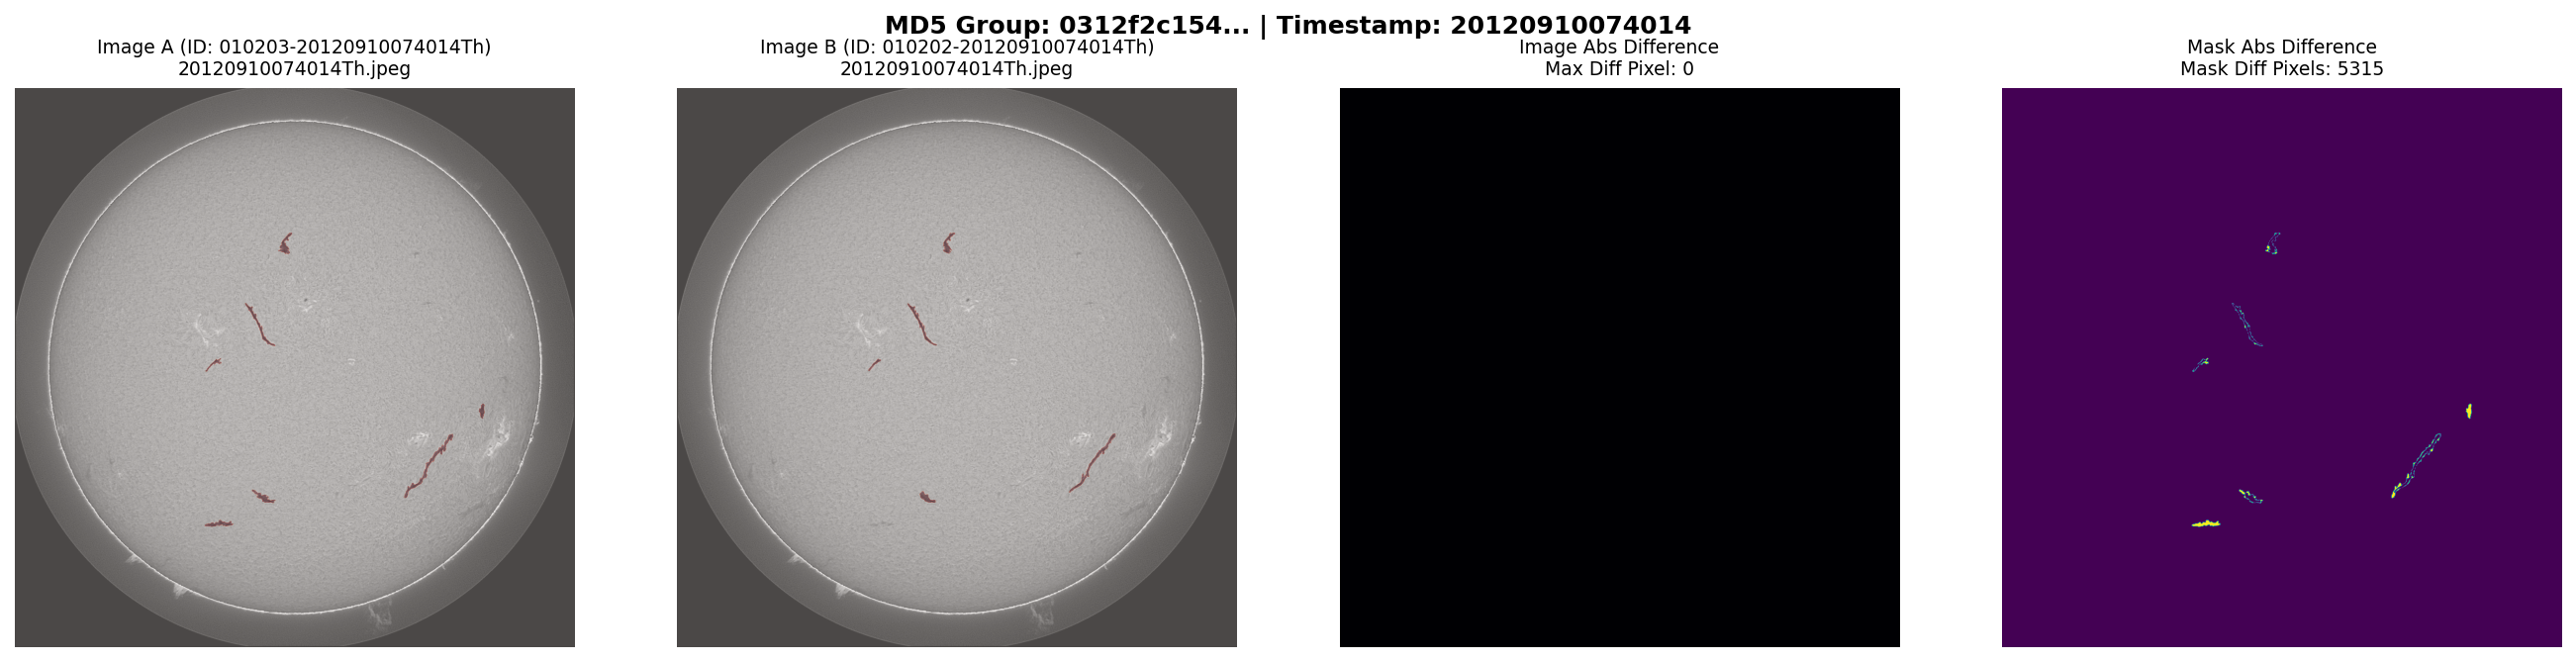

In [40]:
df_groups = pd.read_csv("train_image_groups.csv")
# Find MD5 hash groups that have at least 2 images
dup_hash_groups = (
    df_groups.groupby("md5_hash")
    .filter(lambda x: len(x) >= 2)
    .groupby("md5_hash")
)

# Render the first 3 duplicate groups for visual comparison
num_groups_to_plot = 3
plt_idx = 1

print("Rendering visual duplicate comparisons...")

for hash_val, group in list(dup_hash_groups)[:num_groups_to_plot]:
    records = group.to_dict("records")
    rec_a, rec_b = records[0], records[1]

    img_path_a = os.path.join(train_img_dir, rec_a["file_name"])
    img_path_b = os.path.join(train_img_dir, rec_b["file_name"])

    img_a = cv2.imread(img_path_a, cv2.IMREAD_GRAYSCALE)
    img_b = cv2.imread(img_path_b, cv2.IMREAD_GRAYSCALE)

    if img_a is None or img_b is None:
        continue

    # Generate masks for both images
    mask_a = np.zeros_like(img_a, dtype=np.uint8)
    for ann in annotations_by_img_id.get(rec_a["image_id"], []):
        for poly in ann.get("segmentation", []):
            pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
            cv2.fillPoly(mask_a, [pts], 1)

    mask_b = np.zeros_like(img_b, dtype=np.uint8)
    for ann in annotations_by_img_id.get(rec_b["image_id"], []):
        for poly in ann.get("segmentation", []):
            pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
            cv2.fillPoly(mask_b, [pts], 1)

    # Pixel-wise difference
    img_diff = cv2.absdiff(img_a, img_b)
    mask_diff = cv2.absdiff(mask_a, mask_b)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), dpi=150)
    fig.suptitle(
        f"MD5 Group: {hash_val[:10]}... | Timestamp: {rec_a['timestamp_prefix']}",
        fontsize=12,
        fontweight="bold",
    )

    # Image A
    axes[0].imshow(img_a, cmap="gray")
    axes[0].imshow(mask_a, cmap="Reds", alpha=0.3)
    axes[0].set_title(
        f"Image A (ID: {rec_a['image_id']})\n{rec_a['file_name']}", fontsize=9
    )
    axes[0].axis("off")

    # Image B
    axes[1].imshow(img_b, cmap="gray")
    axes[1].imshow(mask_b, cmap="Reds", alpha=0.3)
    axes[1].set_title(
        f"Image B (ID: {rec_b['image_id']})\n{rec_b['file_name']}", fontsize=9
    )
    axes[1].axis("off")

    # Absolute Image Difference
    axes[2].imshow(img_diff, cmap="magma")
    axes[2].set_title(
        f"Image Abs Difference\nMax Diff Pixel: {np.max(img_diff)}", fontsize=9
    )
    axes[2].axis("off")

    # Absolute Mask Difference
    axes[3].imshow(mask_diff, cmap="viridis")
    axes[3].set_title(
        f"Mask Abs Difference\nMask Diff Pixels: {np.sum(mask_diff)}",
        fontsize=9,
    )
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

here we see that "duplicated" images has different annotation masks covering very different objects on the image, so better strategy to handle this would be not just dropping, but merging their annotations to get fully covered labelmasks

In [41]:
# Group image_ids by MD5 hash
hash_to_img_ids = (
    df_groups.groupby("md5_hash")["image_id"].apply(list).to_dict()
)

# Map annotations to their respective MD5 hashes
hash_to_anns = {}
for ann in data.get("annotations", []):
    img_id = ann["image_id"]
    # Find matching hash
    matching_hash = df_groups.loc[
        df_groups["image_id"] == img_id, "md5_hash"
    ].values[0]
    hash_to_anns.setdefault(matching_hash, []).append(ann)

# Build fused dataset
fused_images = []
fused_annotations = []
ann_id_counter = 1

print("Fusing duplicate annotations into clean ground-truth targets...")

for md5_hash, img_ids in tqdm(hash_to_img_ids.items()):
    # Pick the primary image record to keep
    primary_img_id = img_ids[0]
    primary_img_info = next(
        img for img in data["images"] if img["id"] == primary_img_id
    )

    # Collect all annotations across ALL duplicate records in this hash group
    group_anns = hash_to_anns.get(md5_hash, [])

    # Re-assign all annotations to the primary_img_id
    for ann in group_anns:
        new_ann = ann.copy()
        new_ann["id"] = ann_id_counter
        new_ann["image_id"] = primary_img_id
        fused_annotations.append(new_ann)
        ann_id_counter += 1

    fused_images.append(primary_img_info)

fused_coco = {
    "info": data.get("info", {}),
    "licenses": data.get("licenses", []),
    "categories": data.get("categories", []),
    "images": fused_images,
    "annotations": fused_annotations,
}

output_path = train_lbl_file.replace(".json", "_fused_deduplicated.json")
with open(output_path, "w") as f:
    json.dump(fused_coco, f, indent=2)

print("\n=== ANNOTATION FUSION COMPLETE ===")
print(
    f"Unique Solar Images: {len(data['images'])} -> {len(fused_images)} clean frames"
)
print(f"Total Preserved Filament Annotations: {len(fused_annotations)}")
print(f"Saved fused COCO JSON to: {output_path}")

Fusing duplicate annotations into clean ground-truth targets...


  0%|          | 0/707 [00:00<?, ?it/s]


=== ANNOTATION FUSION COMPLETE ===
Unique Solar Images: 1154 -> 707 clean frames
Total Preserved Filament Annotations: 8199
Saved fused COCO JSON to: X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json


Leakage free stratified GroupKSplit

In [17]:
from collections import defaultdict
from sklearn.model_selection import GroupKFold

In [18]:
import re
import pandas as pd
fused_json_path = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json"

with open(fused_json_path, "r") as f:
    data_fused = json.load(f)
img_counts = defaultdict(int)

for ann in data_fused["annotations"]:
    img_counts[ann["image_id"]] += 1

ts_pattern = re.compile(r"(\d{8})")
records = []

for img in data_fused["images"]:
    match = ts_pattern.search(img["file_name"])
    date_day = match.group(1) if match else "Unknown"
    records.append(
        {
            "image_id": img["id"],
            "file_name": img["file_name"],
            "date_day": date_day,
            "ann_count": img_counts[img["id"]],
        }
    )

df_split = pd.DataFrame(records)

In [19]:
# 5-Fold GroupKFold by Date
gkf = GroupKFold(n_splits=5)
df_split["fold"] = -1
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df_split, groups=df_split["date_day"])
):
    df_split.loc[val_idx, "fold"] = fold

print("=== 5-FOLD TEMPORAL GROUP SPLIT SUMMARY ===")
for f in range(5):
    sub = df_split[df_split["fold"] == f]
    print(
        f"Fold {f}: {len(sub)} images | {sub['date_day'].nunique()} unique days | {sub['ann_count'].sum()} filaments"
    )

df_split[["image_id", "file_name", "date_day", "fold"]].to_csv(
    "clean_fused_folds.csv", index=False
)

=== 5-FOLD TEMPORAL GROUP SPLIT SUMMARY ===
Fold 0: 142 images | 131 unique days | 1620 filaments
Fold 1: 142 images | 132 unique days | 1586 filaments
Fold 2: 141 images | 131 unique days | 1660 filaments
Fold 3: 141 images | 131 unique days | 1755 filaments
Fold 4: 141 images | 131 unique days | 1578 filaments


In [45]:
def analyze_disk_intensities(coco_json, img_dir):
    with open(coco_json, "r") as f:
        coco = json.load(f)

    disk_pixels, off_disk_pixels = [], []

    for img_info in coco["images"][:50]:  # Sample 50 frames
        img_path = os.path.join(img_dir, img_info["file_name"])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Simple disk threshold mask (Solar disk is bright relative to outer space)
        _, disk_mask = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)

        disk_pixels.extend(img[disk_mask == 255])
        off_disk_pixels.extend(img[disk_mask == 0])

    print("=== SOLAR DISK vs OFF-DISK INTENSITY PROFILE ===")
    print(
        f"Off-Disk Space  -> Mean: {np.mean(off_disk_pixels):.2f} | P95: {np.percentile(off_disk_pixels, 95):.2f}"
    )
    print(
        f"On-Disk Surface -> Mean: {np.mean(disk_pixels):.2f} | P5: {np.percentile(disk_pixels, 5):.2f} | Median: {np.median(disk_pixels):.2f}"
    )


analyze_disk_intensities(
    fused_json_path,
    r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images",
)

=== SOLAR DISK vs OFF-DISK INTENSITY PROFILE ===
Off-Disk Space  -> Mean: 1.09 | P95: 10.00
On-Disk Surface -> Mean: 109.81 | P5: 29.00 | Median: 123.00


In [46]:
def compute_fused_contrast_distribution(coco_json, img_dir):
    with open(coco_json, "r") as f:
        coco = json.load(f)

    imgs = {img["id"]: img for img in coco["images"]}
    contrasts = []

    for ann in coco["annotations"]:
        img_info = imgs.get(ann["image_id"])
        if not img_info:
            continue
        img = cv2.imread(
            os.path.join(img_dir, img_info["file_name"]), cv2.IMREAD_GRAYSCALE
        )
        if img is None:
            continue

        mask = np.zeros_like(img, dtype=np.uint8)
        for poly in ann.get("segmentation", []):
            pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
            cv2.fillPoly(mask, [pts], 1)

        if np.sum(mask) == 0:
            continue

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        dilated = cv2.dilate(mask, kernel, iterations=1)
        bg_ring = np.logical_and(dilated == 1, mask == 0)

        mean_fil = np.mean(img[mask == 1])
        mean_bg = np.mean(img[bg_ring]) if np.sum(bg_ring) > 0 else mean_fil
        contrasts.append(mean_bg - mean_fil)

    print("\n=== LOCAL CONTRAST DISTRIBUTION (FUSED DATASET) ===")
    print(
        f"Min: {np.min(contrasts):.2f} | P25: {np.percentile(contrasts, 25):.2f} | Median: {np.median(contrasts):.2f} | P75: {np.percentile(contrasts, 75):.2f} | Max: {np.max(contrasts):.2f}"
    )


compute_fused_contrast_distribution(
    fused_json_path,
    r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images",
)


=== LOCAL CONTRAST DISTRIBUTION (FUSED DATASET) ===
Min: 0.87 | P25: 11.20 | Median: 14.45 | P75: 18.32 | Max: 51.34


In [47]:
def compute_panoptic_quality(
    pred_masks, gt_masks, iou_threshold=0.5
):
    """Calculates Panoptic Quality (PQ), Segmentation Quality (SQ), and Recognition Quality (RQ).

    pred_masks, gt_masks: List of binary 2D numpy arrays [H, W]
    """
    if len(gt_masks) == 0 and len(pred_masks) == 0:
        return 1.0, 1.0, 1.0
    if len(gt_masks) == 0 or len(pred_masks) == 0:
        return 0.0, 0.0, 0.0

    iou_matrix = np.zeros((len(pred_masks), len(gt_masks)))
    for p_idx, p_mask in enumerate(pred_masks):
        for g_idx, g_mask in enumerate(gt_masks):
            intersection = np.logical_and(p_mask, g_mask).sum()
            union = np.logical_or(p_mask, g_mask).sum()
            iou_matrix[p_idx, g_idx] = (
                intersection / union if union > 0 else 0.0
            )

    # Match predictions to GT using IoU > iou_threshold
    matched_preds, matched_gts = set(), set()
    iou_sum = 0.0
    tp = 0

    for p_idx in range(len(pred_masks)):
        for g_idx in range(len(gt_masks)):
            if p_idx in matched_preds or g_idx in matched_gts:
                continue
            if iou_matrix[p_idx, g_idx] >= iou_threshold:
                matched_preds.add(p_idx)
                matched_gts.add(g_idx)
                iou_sum += iou_matrix[p_idx, g_idx]
                tp += 1

    fp = len(pred_masks) - tp
    fn = len(gt_masks) - tp

    if tp == 0:
        return 0.0, 0.0, 0.0

    sq = iou_sum / tp
    rq = tp / (tp + 0.5 * fp + 0.5 * fn)
    pq = sq * rq

    return pq, sq, rq


# Unit Test with Synthetic Data
gt_test = [np.ones((50, 50), dtype=np.uint8)]
pred_test = [np.ones((50, 50), dtype=np.uint8)]
pq, sq, rq = compute_panoptic_quality(pred_test, gt_test)
print(
    f"\n=== PQ EVALUATOR UNIT TEST ===\nPQ: {pq:.4f} | SQ: {sq:.4f} | RQ: {rq:.4f}"
)


=== PQ EVALUATOR UNIT TEST ===
PQ: 1.0000 | SQ: 1.0000 | RQ: 1.0000


1. всего 7-9 пар имели соприкасание в пикселях между filaments что значительно упростило необходимость использовать instance segmentation разделяя каждый объект чтобы PQ не снижался

2. мы сравнили среднюю яркость фона диска солнечного и filaments где среднее второго оказался выше ЛОЖНО указывая на то что это яркие объекты, но это не так
 - отличать disk space(область солнечного круга) и не обращать внимание на фон черного космоса
 - из за темного фона вокруг может выдавать много нулей если диск маленький что искуственно увеличивает accuracy -> BCE+Dice Loss чтобы сфокусировать на диск или вовсе не выделять градиенты изучению фона

3. Для аугментации играться обычным увеличением яркости и тд опасно, поэтому прибегать к CLAHE - локальное усиление контраста

In [20]:
# 1. Загрузка исходных и дедуплицированных данных
raw_json_path = train_lbl_file
fused_json_path = os.path.join(
    os.path.dirname(train_lbl_file),
    "MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json",
)

with open(raw_json_path, "r") as f:
    raw_coco = json.load(f)

with open(fused_json_path, "r") as f:
    fused_coco = json.load(f)

print("=== 1. Проверка объемов данных ===")
print(
    f"Исходно: {len(raw_coco['images'])} изображений | {len(raw_coco['annotations'])} аннотаций"
)
print(
    f"После слияния: {len(fused_coco['images'])} изображений | {len(fused_coco['annotations'])} аннотаций"
)
print(
    f"Сокращение объема картинок: {(1 - len(fused_coco['images'])/len(raw_coco['images']))*100:.1f}%"
)

=== 1. Проверка объемов данных ===
Исходно: 1154 изображений | 8199 аннотаций
После слияния: 707 изображений | 8199 аннотаций
Сокращение объема картинок: 38.7%


In [21]:
# 2. Проверка уникальности файлов и ID
fused_img_ids = [img["id"] for img in fused_coco["images"]]
fused_filenames = [img["file_name"] for img in fused_coco["images"]]
assert len(fused_img_ids) == len(
    set(fused_img_ids)
), "ОШИБКА: Найдены дубликаты image_id!"
assert len(fused_filenames) == len(
    set(fused_filenames)
), "ОШИБКА: Найдены дубликаты file_name!"
print(
    "\n=== 2. Уникальность ключей: УСПЕШНО (Нет повторяющихся ID или имен) ==="
)

# 3. Валидация привязки аннотаций (Orphan Check)
valid_img_ids = set(fused_img_ids)
ann_img_ids = set(ann["image_id"] for ann in fused_coco["annotations"])
orphaned_anns = ann_img_ids - valid_img_ids
assert (
    len(orphaned_anns) == 0
), f"ОШИБКА: Найдены осиротевшие аннотации для ID: {orphaned_anns}"
print(
    "=== 3. Валидация связей: УСПЕШНО (Все аннотации привязаны к существующим картинкам) ==="
)


=== 2. Уникальность ключей: УСПЕШНО (Нет повторяющихся ID или имен) ===
=== 3. Валидация связей: УСПЕШНО (Все аннотации привязаны к существующим картинкам) ===


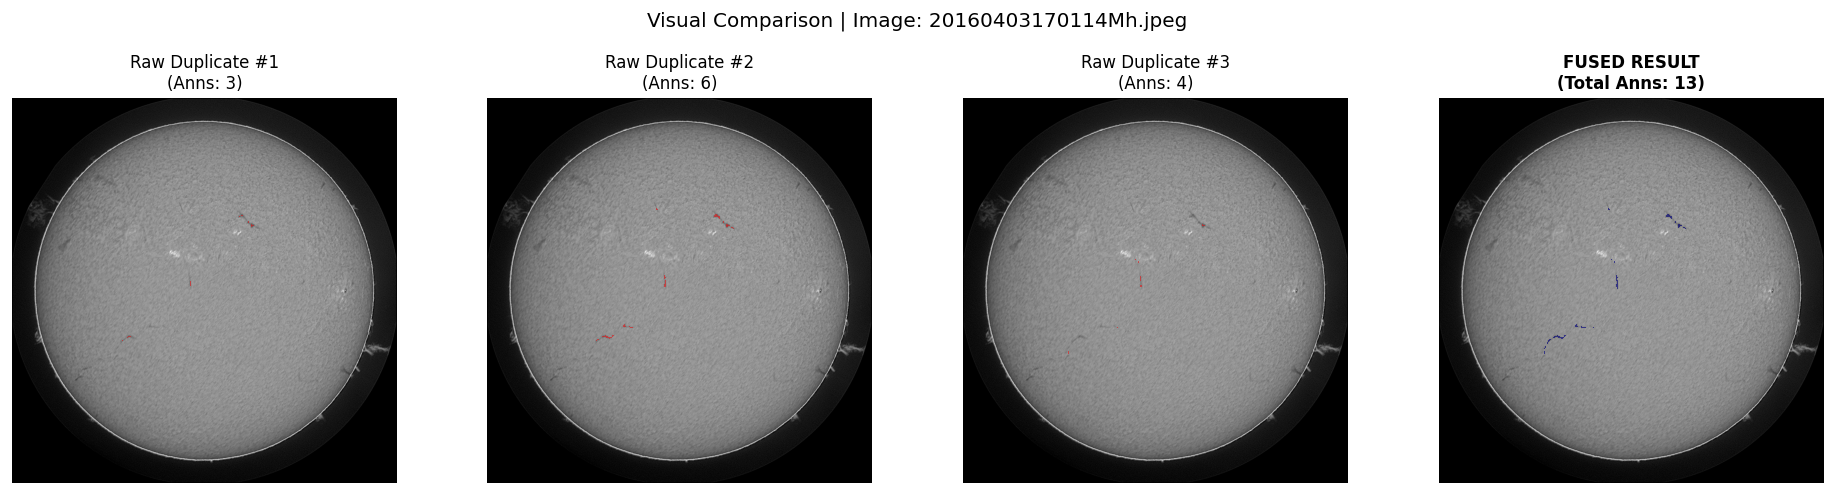

In [22]:
import random

# 1. Собираем карты аннотаций
raw_anns_by_img = {}
for ann in raw_coco["annotations"]:
    raw_anns_by_img.setdefault(ann["image_id"], []).append(ann)

fused_anns_by_img = {}
for ann in fused_coco["annotations"]:
    fused_anns_by_img.setdefault(ann["image_id"], []).append(ann)

# 2. Фильтруем ВСЕ изображения из fused_coco, у которых 3+ аннотаций
candidate_images = [
    img
    for img in fused_coco["images"]
    if len(fused_anns_by_img.get(img["id"], [])) >= 3
]

# 3. ВЫБИРАЕМ СЛУЧАЙНОЕ ИЗОБРАЖЕНИЕ из кандидатов
sample_fused_img = random.choice(candidate_images)
fused_img_id = sample_fused_img["id"]
target_filename = sample_fused_img["file_name"]

# 4. Ищем все оригинальные записи из raw_coco для этой картинки
raw_dup_images = [
    img for img in raw_coco["images"] if img["file_name"] == target_filename
]

dup_count = len(raw_dup_images)
fused_anns = fused_anns_by_img.get(fused_img_id, [])

# 5. Отрисовка (динамическая подстройка размеров под количество дубликатов)
if dup_count > 1:
    fig, axes = plt.subplots(
        1, dup_count + 1, figsize=(4 * (dup_count + 1), 4), dpi=120
    )

    img_path = os.path.join(train_img_dir, target_filename)
    base_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    h, w = base_img.shape

    # Рендерим фрагментарные исходные маски
    for idx, dup_img_info in enumerate(raw_dup_images):
        raw_mask = np.zeros((h, w), dtype=np.uint8)
        anns = raw_anns_by_img.get(dup_img_info["id"], [])

        for ann in anns:
            for poly in ann.get("segmentation", []):
                pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
                cv2.fillPoly(raw_mask, [pts], 1)

        axes[idx].imshow(base_img, cmap="gray")
        axes[idx].imshow(
            np.ma.masked_where(raw_mask == 0, raw_mask), cmap="Set1", alpha=0.6
        )
        axes[idx].set_title(
            f"Raw Duplicate #{idx+1}\n(Anns: {len(anns)})", fontsize=10
        )
        axes[idx].axis("off")

    # Рендерим итоговый FUSED результат
    fused_mask = np.zeros((h, w), dtype=np.uint8)
    for ann in fused_anns:
        for poly in ann.get("segmentation", []):
            pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
            cv2.fillPoly(fused_mask, [pts], 1)

    axes[-1].imshow(base_img, cmap="gray")
    axes[-1].imshow(
        np.ma.masked_where(fused_mask == 0, fused_mask), cmap="jet", alpha=0.6
    )
    axes[-1].set_title(
        f"FUSED RESULT\n(Total Anns: {len(fused_anns)})",
        fontsize=10,
        fontweight="bold",
    )
    axes[-1].axis("off")

    plt.suptitle(
        f"Visual Comparison | Image: {target_filename}", fontsize=12, y=1.02
    )
    plt.tight_layout()
    plt.show()
else:
    print(
        f"У изображения {target_filename} совпадение было по хэшу пикселей, а не по file_name. Запустите ячейку еще раз для выборки другого кадра."
    )

### Validation split

In [15]:
import torch 
from torch.utils.data import Dataset, DataLoader
import albumentations as A 
from albumentations.pytorch import ToTensorV2

c:\Users\User\anaconda3\envs\tensorflowgpu\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [71]:
torch.__version__

'2.5.1+cu118'

In [16]:
# --- 1. Формирование GroupKFold Сплита ---

def create_grouped_folds(coco_json_path, n_splits=5):
    with open(coco_json_path, "r") as f:
        coco_data = json.load(f)

    df_images = pd.DataFrame(coco_data["images"])

    df_images['group_date'] = df_images['file_name'].apply(lambda x: x[:8])

    gkf = GroupKFold(n_splits=n_splits)
    df_images["fold"] = -1

    for fold, (train_idx, val_idx) in enumerate(gkf.split(df_images, groups=df_images['group_date'])):
        df_images.loc[val_idx, 'fold'] = fold
        
    print(f"Dataset split into {n_splits} folds based on observation dates.")
    print(df_images['fold'].value_counts().sort_index())
    return df_images, coco_data

# --- 2. Albumentations Пайплайны ---
def get_train_transforms(img_size=512):
    return A.Compose([
        A.RandomCrop(width=img_size, height=img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
        ToTensorV2(),
    ], bbox_params=None)

def get_val_transforms():
    return A.Compose([
        ToTensorV2(),
    ])

In [ ]:
# --- 3. Custom PyTorch Dataset с CLAHE и Маской Диска ---

class SolarFilamentDataset(Dataset):
    def __init__(self, df_images, 
                 
                 
                 
                 , img_dir, transform=None, is_train=True):
        self.df_images = df_images.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_train = is_train

        self.anns_by_img = {}
        for ann in coco_data['annotations']:
            self.anns_by_img.setdefault(ann['image_id'], []).append(ann)

        self.clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        
    def __len__(self):
        return len(self.df_images)

    def __getitem__(self, idx):
        img_info = self.df_images.iloc[idx]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        h, w = image.shape
# 1. Построение маски Ground Truth из COCO полигонов
        mask = np.zeros((h, w), dtype=np.float32)

        anns = self.anns_by_img.get(img_info['id'], [])
        for ann in anns:
            for poly in ann.get('segmentation', []):
                pts = np.array(poly, dtype=np.int32).reshape((-1,2))
                cv2.fillPoly(mask, [pts], 1.0)
# 2. Препроцессинг: Маска диска ($I > 15$) + CLAHE
        disk_mask = image > 15
        processed_img = image.copy()

        # Применяем CLAHE только к пикселям внутри диска
        if np.any(disk_mask):
            enhanced_disk = self.clahe.apply(image)
            processed_img[disk_mask] = enhanced_disk[disk_mask]
            
        # Нормализация в диапазон [0.0, 1.0] и превращение в 3-канальное изображение (для бэкбонов ResNet/EfficientNet)
        processed_img = processed_img.astype(np.float32) / 255.0
        processed_img = np.stack([processed_img] * 3, axis=-1)

        # 3. Аугментации Albumentations
        if self.transform:
            augmented = self.transform(image=processed_img, mask=mask)
            processed_img = augmented['image']
            mask = augmented['mask']
            
        # Добавляем канальную размерность для маски: (H, W) -> (1, H, W)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return processed_img, mask


In [18]:
fused_json_path

'X:\\Desktop\\kaggle\\solar_project_cv\\notebooks\\MAGFiLO_1.0_Kaggle_2026\\train\\MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json'

In [19]:
# 2. Создаем фолды
df_images, coco_data = create_grouped_folds(fused_json_path, n_splits=5)

# 3. Делим на Train и Val для Fold 0
df_train = df_images[df_images["fold"] != 0]
df_val = df_images[df_images["fold"] == 0]

Dataset split into 5 folds based on observation dates.
fold
0    142
1    142
2    141
3    141
4    141
Name: count, dtype: int64


In [20]:

# 4. Создаем Dataset объекты
train_dataset = SolarFilamentDataset(
    df_train,
    coco_data,
    train_img_dir,
    transform=get_train_transforms(img_size=512),
    is_train=True,
)

val_dataset = SolarFilamentDataset(
    df_val,
    coco_data,
    train_img_dir,
    transform=get_val_transforms(),
    is_train=False,
)

In [21]:
train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False, num_workers=0, pin_memory=True
)

In [22]:
# 6. Sanity Check (Проверка одного батча)
images_batch, masks_batch = next(iter(train_loader))

print("\n=== Sanity Check Passed! ===")
print(f"Images batch shape: {images_batch.shape} (Ожидается: [B, 3, 512, 512])")
print(f"Masks batch shape:  {masks_batch.shape}  (Ожидается: [B, 1, 512, 512])")
print(
    f"Image dtype: {images_batch.dtype} | Range: [{images_batch.min():.2f}, {images_batch.max():.2f}]"
)
print(
    f"Mask dtype:  {masks_batch.dtype}  | Unique values: {torch.unique(masks_batch)}"
)


=== Sanity Check Passed! ===
Images batch shape: torch.Size([8, 3, 512, 512]) (Ожидается: [B, 3, 512, 512])
Masks batch shape:  torch.Size([8, 1, 512, 512])  (Ожидается: [B, 1, 512, 512])
Image dtype: torch.float32 | Range: [0.00, 0.98]
Mask dtype:  torch.float32  | Unique values: tensor([0., 1.])


### Combined Loss Function

In [23]:
import torch.nn as nn 
import torch.nn.functional as F  

In [24]:
class BCEDiceLoss(nn.Module):

    def __init__(self, bce_weight=0.5, smooth=1e-6):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        #BCE Loss
        bce_loss = self.bce(logits, targets)

        #Dice Loss
        probs = torch.sigmoid(logits)

        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)

        intersection = (probs_flat * targets_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1.0 - dice_score

        total_loss = (self.bce_weight * bce_loss) + ((1-self.bce_weight) * dice_loss)

        return total_loss, dice_score

### Baseline training (simple U-Net with resnet34 backbone)

In [25]:
import segmentation_models_pytorch as smp
from tqdm import tqdm

# --- Инициализация Модели, Loss и Оптимизатора ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)

Device:  cuda


In [26]:
model = smp.Unet(
    encoder_name="resnet34",        # Легкий проверенный бэкбон
    encoder_weights="imagenet",     # Предобученные веса
    in_channels=3,                  # 3 канала из даталоадера
    classes=1,                      # Бинарная сегментация
).to(device)

criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)

# --- Функция обучения одной эпохи ---
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        logits = model(images)
        
        loss, dice = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_dice += dice.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "dice": f"{dice.item():.4f}"})
        
    return running_loss / len(loader), running_dice / len(loader)

# --- Функция валидации ---
@torch.no_grad()
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    
    pbar = tqdm(loader, desc="Validating", leave=False)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        logits = model(images)
        loss, dice = criterion(logits, masks)
        
        running_loss += loss.item()
        running_dice += dice.item()
        pbar.set_postfix({"val_loss": f"{loss.item():.4f}", "val_dice": f"{dice.item():.4f}"})
        
    return running_loss / len(loader), running_dice / len(loader)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:01<00:00, 62.3MB/s]


In [27]:
EPOCHS = 15
best_val_dice = 0.0

print(f"Starting Baseline Training on Fold 0 ({device})...\n")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_dice = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step()
    
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | "
          f"Train Loss: {train_loss:.4f} - Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} - Val Dice: {val_dice:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Сохраняем лучшую модель
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "unet_resnet34_fold0_best.pth")
        print(f"  >>> Model saved! New Best Val Dice: {best_val_dice:.4f}")

print(f"\nTraining Complete! Best Val Dice Score: {best_val_dice:.4f}")

Starting Baseline Training on Fold 0 (cuda)...



Epoch 01/15 | Train Loss: 0.6616 - Train Dice: 0.0249 | Val Loss: 0.5840 - Val Dice: 0.0327 | LR: 0.000297
  >>> Model saved! New Best Val Dice: 0.0327


Epoch 02/15 | Train Loss: 0.5383 - Train Dice: 0.0691 | Val Loss: 0.5169 - Val Dice: 0.0718 | LR: 0.000287
  >>> Model saved! New Best Val Dice: 0.0718


Epoch 03/15 | Train Loss: 0.4676 - Train Dice: 0.1374 | Val Loss: 0.4502 - Val Dice: 0.1413 | LR: 0.000271
  >>> Model saved! New Best Val Dice: 0.1413


Epoch 04/15 | Train Loss: 0.3867 - Train Dice: 0.2690 | Val Loss: 0.4332 - Val Dice: 0.2112 | LR: 0.000251
  >>> Model saved! New Best Val Dice: 0.2112


...

Epoch 11/15 | Train Loss: 0.2098 - Train Dice: 0.6049 | Val Loss: 0.1950 - Val Dice: 0.6262 | LR: 0.000050
  >>> Model saved! New Best Val Dice: 0.6262


Epoch 12/15 | Train Loss: 0.1980 - Train Dice: 0.6290 | Val Loss: 0.1922 - Val Dice: 0.6316 | LR: 0.000030
  >>> Model saved! New Best Val Dice: 0.6316


Epoch 13/15 | Train Loss: 0.1938 - Train Dice: 0.6370 | Val Loss: 0.1919 - Val Dice: 0.6322 | LR: 0.000014
  >>> Model saved! New Best Val Dice: 0.6322


Epoch 14/15 | Train Loss: 0.1988 - Train Dice: 0.6285 | Val Loss: 0.1874 - Val Dice: 0.6411 | LR: 0.000004
  >>> Model saved! New Best Val Dice: 0.6411


Epoch 15/15 | Train Loss: 0.1912 - Train Dice: 0.6417 | Val Loss: 0.1865 - Val Dice: 0.6434 | LR: 0.000001
  >>> Model saved! New Best Val Dice: 0.6434

Training Complete! Best Val Dice Score: 0.6434


In [29]:
# @torch.no_grad()
# def visualize_predictions(model, val_loader, device, num_samples=3):
#     model.eval()
#     images, masks = next(iter(val_loader))
#     images, masks = images.to(device), masks.to(device)

#     logits = model(images)
#     preds = (torch.sigmoid(logits) > 0.5).float()

#     images = images.cpu().numpy()
#     masks = masks.cpu().numpy()
#     preds = preds.cpu().numpy()

#     fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

#     for i in range(num_samples):
#         # Берём первый канал изображения
#         img = images[i, 0]
#         gt = masks[i, 0]
#         pred = preds[i, 0]

#         axes[i, 0].imshow(img, cmap="gray")
#         axes[i, 0].set_title("Input (CLAHE)")
#         axes[i, 0].axis("off")

#         axes[i, 1].imshow(img, cmap="gray")
#         axes[i, 1].imshow(
#             np.ma.masked_where(gt == 0, gt), cmap="spring", alpha=0.6
#         )
#         axes[i, 1].set_title("Ground Truth")
#         axes[i, 1].axis("off")

#         axes[i, 2].imshow(img, cmap="gray")
#         axes[i, 2].imshow(
#             np.ma.masked_where(pred == 0, pred), cmap="cyan", alpha=0.6
#         )
#         axes[i, 2].set_title("Prediction (Thresh 0.5)")
#         axes[i, 2].axis("off")

#     plt.tight_layout()
#     plt.show()


# visualize_predictions(model, val_loader, device, num_samples=3)

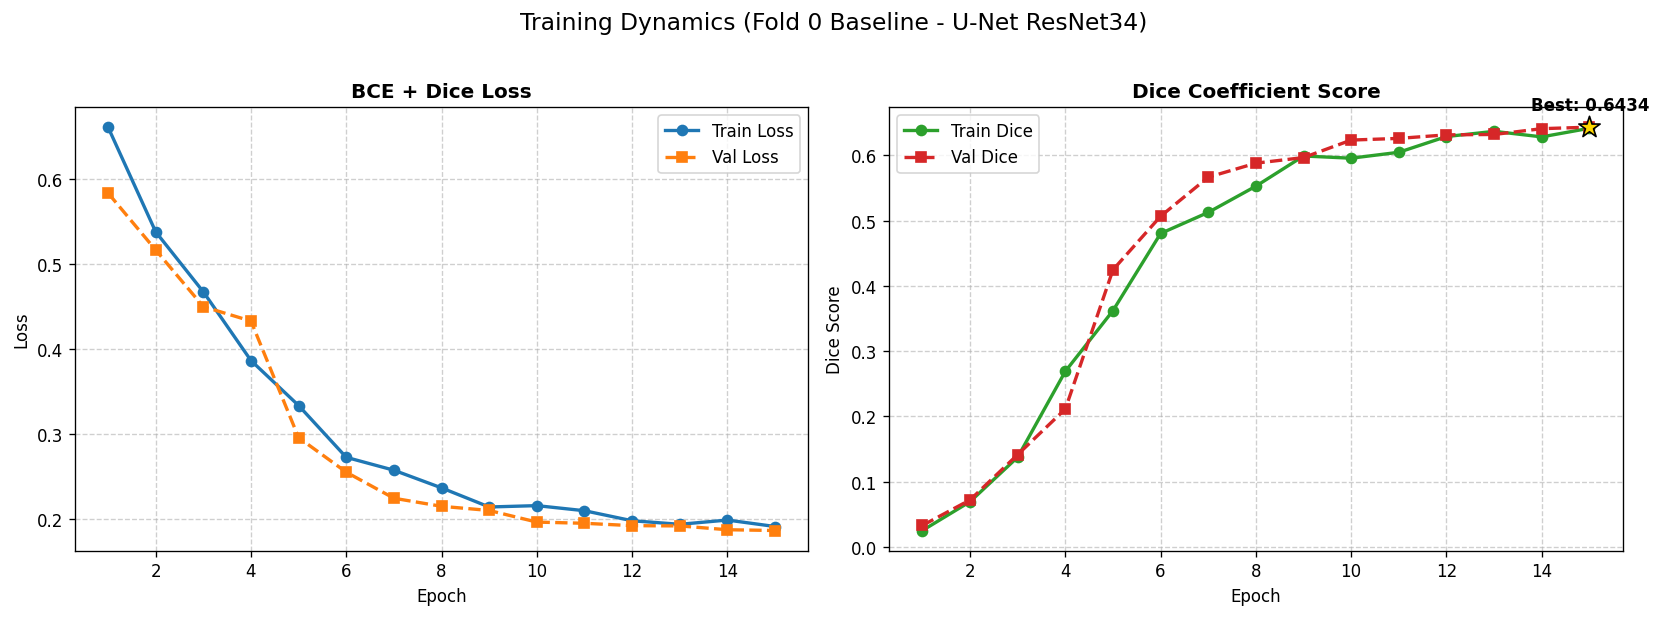

In [30]:
import matplotlib.pyplot as plt

# 1. Полный лог всех 15 эпох
history = {
    "train_loss": [
        0.6616,
        0.5383,
        0.4676,
        0.3867,
        0.3337,
        0.2727,
        0.2575,
        0.2367,
        0.2142,
        0.2158,
        0.2098,
        0.1980,
        0.1938,
        0.1988,
        0.1912,
    ],
    "val_loss": [
        0.5840,
        0.5169,
        0.4502,
        0.4332,
        0.2959,
        0.2552,
        0.2245,
        0.2150,
        0.2101,
        0.1964,
        0.1950,
        0.1922,
        0.1919,
        0.1874,
        0.1865,
    ],
    "train_dice": [
        0.0249,
        0.0691,
        0.1374,
        0.2690,
        0.3621,
        0.4804,
        0.5127,
        0.5529,
        0.5992,
        0.5958,
        0.6049,
        0.6290,
        0.6370,
        0.6285,
        0.6417,
    ],
    "val_dice": [
        0.0327,
        0.0718,
        0.1413,
        0.2112,
        0.4247,
        0.5068,
        0.5667,
        0.5882,
        0.5968,
        0.6236,
        0.6262,
        0.6316,
        0.6322,
        0.6411,
        0.6434,
    ],
}

epochs = range(1, len(history["train_loss"]) + 1)

# 2. Отрисовка
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Loss
ax1.plot(
    epochs,
    history["train_loss"],
    "o-",
    label="Train Loss",
    color="#1f77b4",
    linewidth=2,
)
ax1.plot(
    epochs,
    history["val_loss"],
    "s--",
    label="Val Loss",
    color="#ff7f0e",
    linewidth=2,
)
ax1.set_title("BCE + Dice Loss", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Dice Score
ax2.plot(
    epochs,
    history["train_dice"],
    "o-",
    label="Train Dice",
    color="#2ca02c",
    linewidth=2,
)
ax2.plot(
    epochs,
    history["val_dice"],
    "s--",
    label="Val Dice",
    color="#d62728",
    linewidth=2,
)

# Отметка лучшей эпохи
best_idx = history["val_dice"].index(max(history["val_dice"]))
best_epoch = epochs[best_idx]
best_dice = max(history["val_dice"])

ax2.scatter(
    best_epoch,
    best_dice,
    color="gold",
    s=180,
    zorder=5,
    edgecolors="black",
    marker="*",
)
ax2.annotate(
    f"Best: {best_dice:.4f}",
    (best_epoch, best_dice),
    textcoords="offset points",
    xytext=(-35, 10),
    fontweight="bold",
)

ax2.set_title("Dice Coefficient Score", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice Score")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.suptitle(
    "Training Dynamics (Fold 0 Baseline - U-Net ResNet34)", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

In [31]:
import sys


def get_large_vars():
    vars_size = []
    for var_name, var_val in list(globals().items()):
        if not var_name.startswith("_"):
            try:
                size = sys.getsizeof(var_val)
                # Если это DataFrame, NumPy array или PyTorch Tensor
                if hasattr(var_val, "element_size") and hasattr(
                    var_val, "nelement"
                ):
                    size = var_val.nelement() * var_val.element_size()
                elif hasattr(var_val, "memory_usage"):
                    size = var_val.memory_usage(deep=True).sum()

                size_mb = size / (1024 * 1024)
                if size_mb > 1:  # Показываем переменные тяжелее 1 MB
                    vars_size.append((var_name, type(var_val).__name__, size_mb))
            except:
                pass

    vars_size.sort(key=lambda x: x[2], reverse=True)
    print(f"{'Variable Name':<25} | {'Type':<20} | {'Size (MB)':<10}")
    print("-" * 60)
    for name, vtype, size in vars_size[:10]:
        print(f"{name:<25} | {vtype:<20} | {size:<10.2f}")


get_large_vars()

Variable Name             | Type                 | Size (MB) 
------------------------------------------------------------
images_batch              | Tensor               | 24.00     
masks_batch               | Tensor               | 8.00      


In [32]:
import gc
import torch

# Очищаем временные переменные
if "images_batch" in globals():
    del images_batch
if "masks_batch" in globals():
    del masks_batch

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Память успешно очищена!")

Память успешно очищена!


In [33]:
model

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [35]:
!pip install pycocotools

   ---------------------------------------- 0.0/80.2 kB ? eta -:--:--
   ---------- ----------------------------- 20.5/80.2 kB 640.0 kB/s eta 0:00:01
   ----------------------------------- ---- 71.7/80.2 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 80.2/80.2 kB 1.1 MB/s eta 0:00:00


In [37]:
import pycocotools.mask as mask_utils

# --- 1. RLE Encoder на базе pycocotools ---
def mask_to_rle_counts(binary_mask):
    """
    Кодирует бинарную маску (2048x2048) в RLE string без поля Size.
    """
    # pycocotools ожидает Fortran-contiguous array (uint8)
    rle = mask_utils.encode(np.asfortranarray(binary_mask.astype(np.uint8)))
    # Извлекаем только counts и декодируем байты в utf-8 строку
    rle_counts = rle['counts'].decode('utf-8')
    return rle_counts

# --- 2. Генератор тестовых предсказаний ---
@torch.no_grad()
def generate_submission(model, test_img_dir, device, min_area=20, target_size=2048):
    model.eval()
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    
    submission_rows = []
    test_files = [f for f in os.listdir(test_img_dir) if f.endswith(('.jpeg'))]
    
    print(f"Generating predictions for {len(test_files)} test images...")
    
    for file_name in tqdm(test_files):
        img_id = os.path.splitext(file_name)[0]
        img_path = os.path.join(test_img_dir, file_name)
        
        # 1. Загрузка и CLAHE препроцессинг
        raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if raw_img is None:
            continue
            
        h_orig, w_orig = raw_img.shape
        
        disk_mask = raw_img > 15
        proc_img = raw_img.copy()
        if np.any(disk_mask):
            proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
            
        proc_img = proc_img.astype(np.float32) / 255.0
        proc_img = np.stack([proc_img] * 3, axis=-1)
        
        # Ресайз до 512x512 для прогона через модель
        img_resized = cv2.resize(proc_img, (512, 512))
        tensor_img = torch.tensor(img_resized).permute(2, 0, 1).unsqueeze(0).float().to(device)
        
        # 2. Инференс модели
        logits = model(tensor_img)
        pred_mask = (torch.sigmoid(logits) > 0.5).squeeze().cpu().numpy().astype(np.uint8)
        
        # 3. Возврат маски к родному размеру (2048x2048)
        pred_mask_full = cv2.resize(pred_mask, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)
        
        # 4. Разделение на отдельные компоненты (Instance Segmentation)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(pred_mask_full, connectivity=8)
        
        filament_counter = 1
        for label_idx in range(1, num_labels):
            area = stats[label_idx, cv2.CC_STAT_AREA]
            
            # Пост-обработка: фильтрация микро-шума
            if area < min_area:
                continue
                
            component_mask = (labels == label_idx).astype(np.uint8)
            
            # Кодируем маску одного филамента в RLE
            rle_string = mask_to_rle_counts(component_mask)
            
            # Формируем уникальный filament_id
            filament_id = f"{img_id}_{filament_counter}"
            
            submission_rows.append({
                'filament_id': filament_id,
                'segmentation_rle': rle_string
            })
            filament_counter += 1
            
    df_sub = pd.DataFrame(submission_rows)
    df_sub.to_csv("submission.csv", index=False)
    print(f"\nSubmission file successfully saved! Total filaments predicted: {len(df_sub)}")
    return df_sub

In [42]:
import os

# 1. Задаем точный путь к папке с тестовыми изображениями
test_img_dir = (
    r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"
)

# 2. Проверяем, что папка существует и внутри есть файлы
if os.path.exists(test_img_dir):
    files = [
        f
        for f in os.listdir(test_img_dir)
        if f.lower().endswith((".jpeg", ".jpg", ".png"))
    ]
    print(f"Папка найдена! Найдено изображений для инференса: {len(files)}")
else:
    print(f"ОШИБКА: Путь {test_img_dir} не найден! Проверь правильность диска.")

Папка найдена! Найдено изображений для инференса: 180


In [43]:
# 3. Запускаем генерацию submission.csv
df_sub = generate_submission(
    model=model, test_img_dir=test_img_dir, device=device, min_area=20
)

# 4. Выводим первые 5 строк для проверки формата
df_sub.head()

Generating predictions for 180 test images...


100%|██████████| 180/180 [00:25<00:00,  7.01it/s]


Submission file successfully saved! Total filaments predicted: 348


,filament_id,segmentation_rle
0,20110120105534Ch_1,l]Yb0`0`o10000044H000000<D0000048D0000008H0000...
1,20110130110334Ch_1,`T`f24lo100000H<L00000L400000000000000L8L00000...
2,20110214175414Mh_1,XTXg2<do100000L8L0000008H00000L<H000000<D00000...
3,20110329082654Uh_1,XU`k28ho100000L8L00000L8L000000000000000000000...
4,20110408083214Th_1,PgXh2<do100000H`0H00000L8L00000L40000004L00000...


In [44]:
print("Всего строк в submission:", len(df_sub))
print("Количество уникальных картинок:", df_sub['filament_id'].apply(lambda x: x.rsplit('_', 1)[0]).nunique())

Всего строк в submission: 348
Количество уникальных картинок: 147


In [45]:
# 1. Проверяем отсутствие пропусков (NaN)
assert df_sub.isnull().sum().sum() == 0, "Внимание: есть NaN значения!"

# 2. Проверяем правильные названия колонок
assert list(df_sub.columns) == ['filament_id', 'segmentation_rle'], "Неверные названия колонок!"

# 3. Проверяем, что нет пустых RLE строк
assert (df_sub['segmentation_rle'].str.len() > 0).all(), "Есть пустые RLE строки!"

print("Все проверки пройдены успешно! Файл submission.csv готов к отправке.")

Все проверки пройдены успешно! Файл submission.csv готов к отправке.


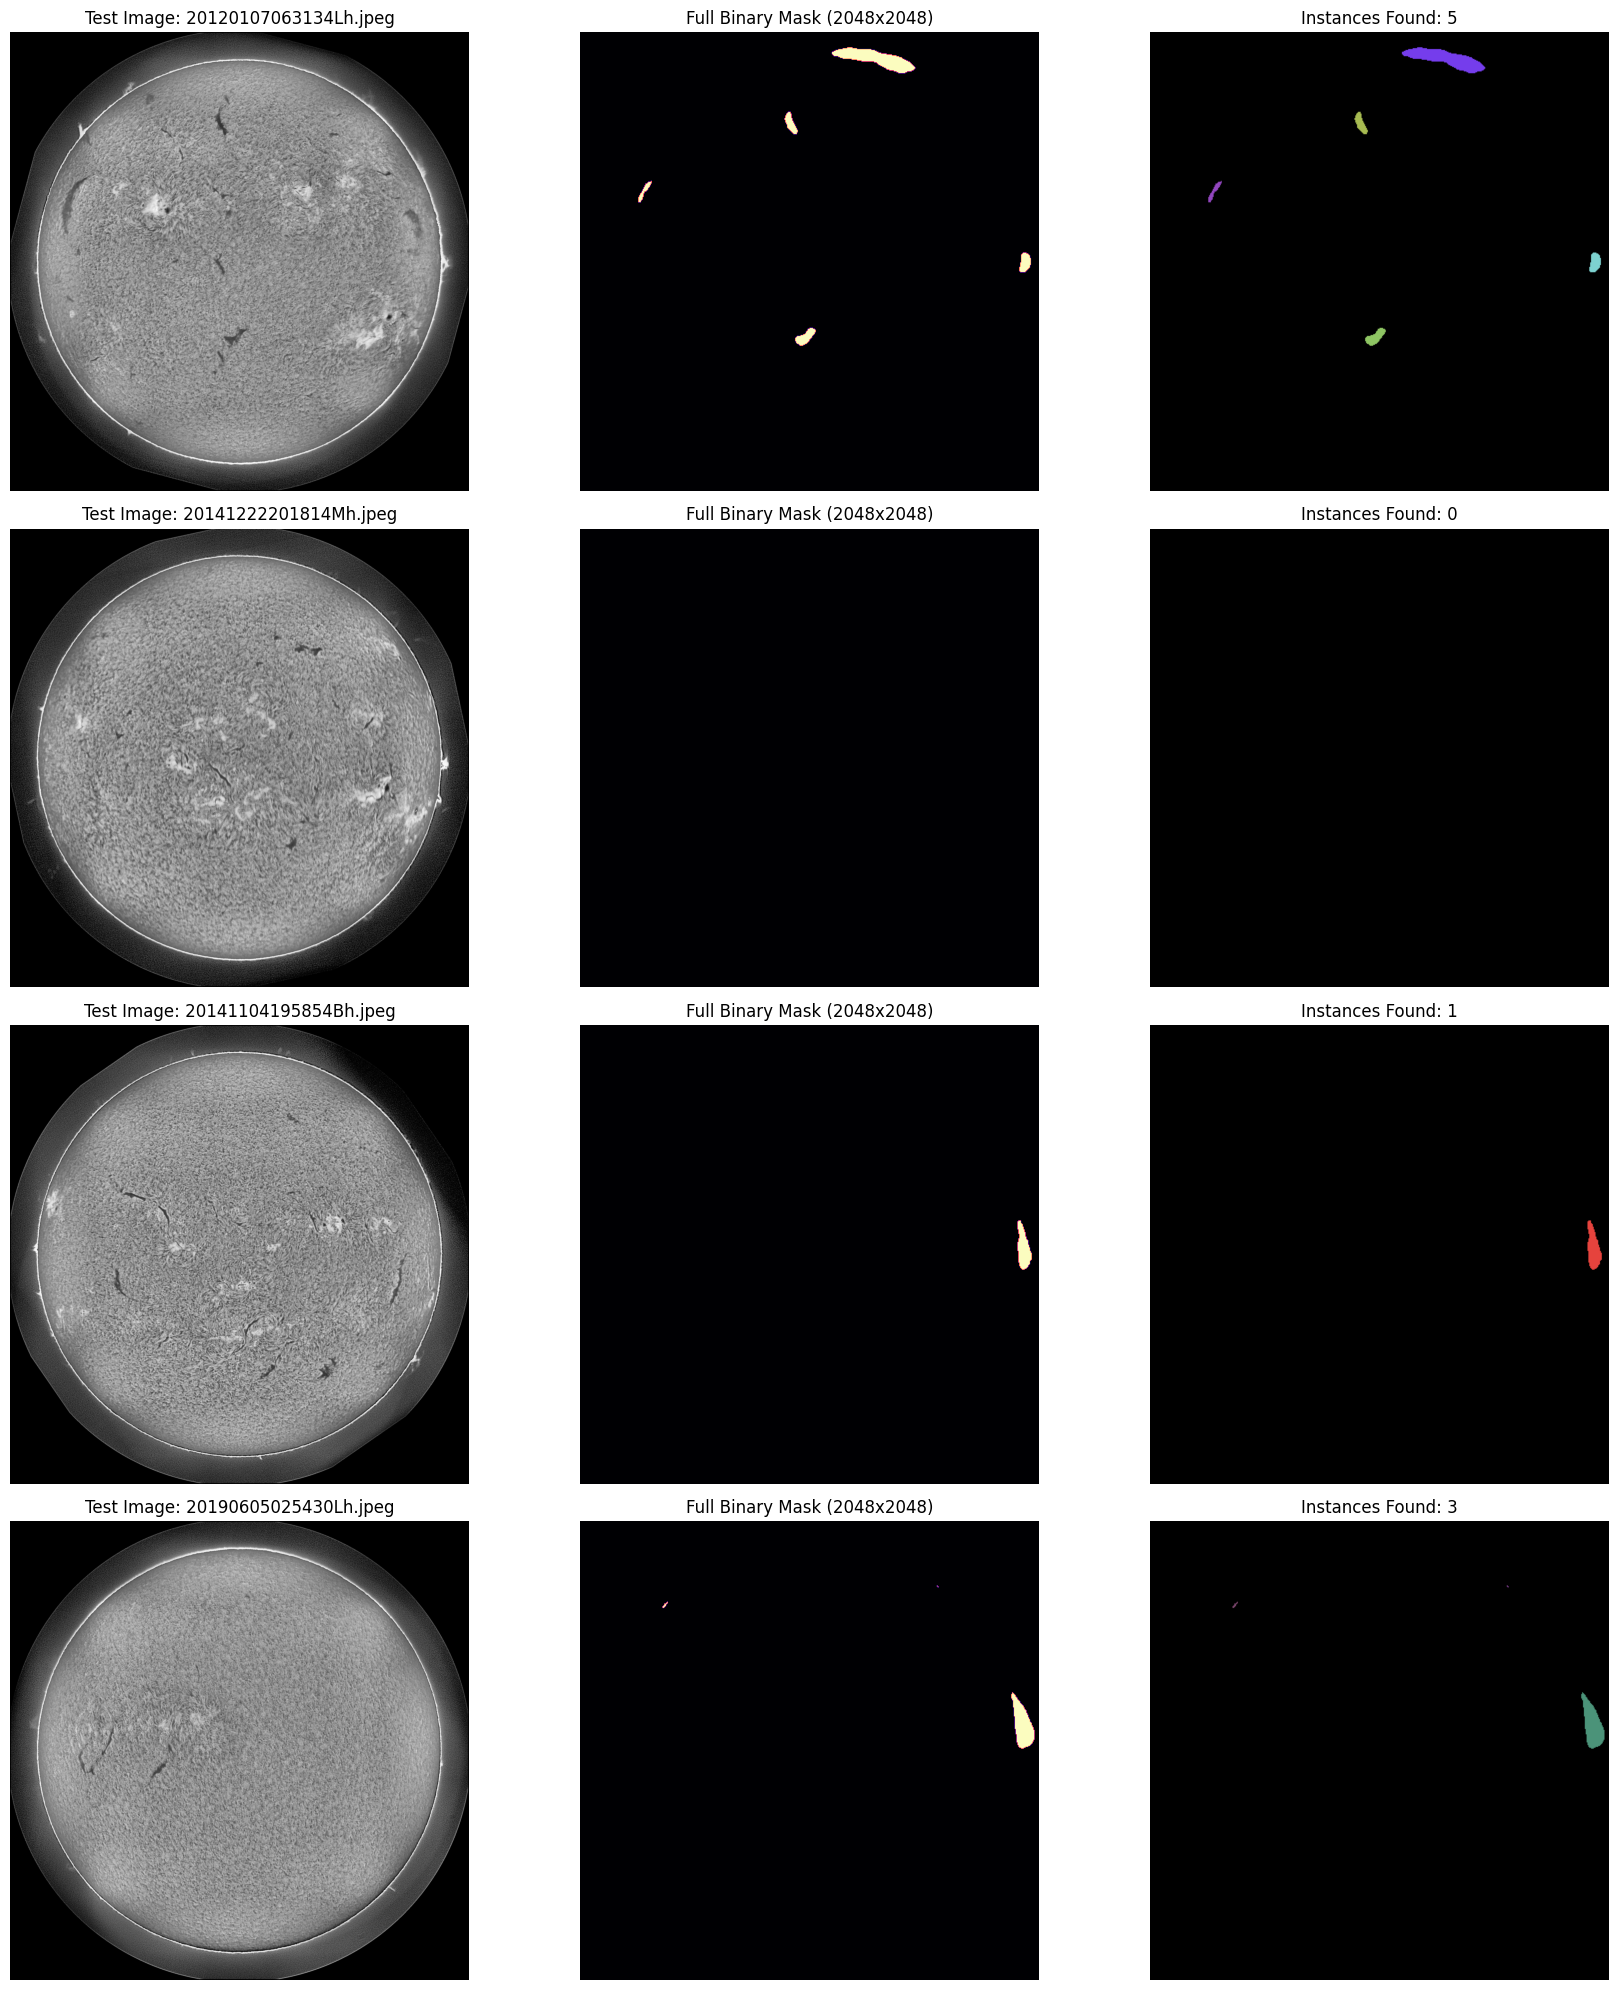

In [47]:

def visualize_test_predictions(model, test_img_dir, device, num_samples=4, min_area=20):
    model.eval()
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    
    test_files = [f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpeg'))]
    sample_files = random.sample(test_files, min(num_samples, len(test_files)))
    
    fig, axes = plt.subplots(len(sample_files), 3, figsize=(18, 5 * len(sample_files)))
    if len(sample_files) == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i, file_name in enumerate(sample_files):
        img_path = os.path.join(test_img_dir, file_name)
        raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        h_orig, w_orig = raw_img.shape
        
        # Препроцессинг
        disk_mask = raw_img > 15
        proc_img = raw_img.copy()
        if np.any(disk_mask):
            proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
            
        proc_img_norm = proc_img.astype(np.float32) / 255.0
        proc_img_3ch = np.stack([proc_img_norm] * 3, axis=-1)
        
        # Инференс (512x512 -> 2048x2048)
        img_resized = cv2.resize(proc_img_3ch, (512, 512))
        tensor_img = torch.tensor(img_resized).permute(2, 0, 1).unsqueeze(0).float().to(device)
        
        with torch.no_grad():
            logits = model(tensor_img)
            pred_mask = (torch.sigmoid(logits) > 0.5).squeeze().cpu().numpy().astype(np.uint8)
            
        pred_mask_full = cv2.resize(pred_mask, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)
        
        # Instance Segmentation & Пост-обработка
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred_mask_full, connectivity=8)
        
        # Создаем цветную карту для визуализации отдельных филаментов
        colored_instances = np.zeros((h_orig, w_orig, 3), dtype=np.uint8)
        valid_filaments = 0
        
        for label_idx in range(1, num_labels):
            if stats[label_idx, cv2.CC_STAT_AREA] >= min_area:
                valid_filaments += 1
                # Генерируем случайный яркий цвет для каждого филамента
                color = [random.randint(50, 255) for _ in range(3)]
                colored_instances[labels == label_idx] = color
                
        # --- Отрисовка ---
        # 1. Оригинальное изображение с CLAHE
        axes[i, 0].imshow(proc_img, cmap='gray')
        axes[i, 0].set_title(f"Test Image: {file_name}")
        axes[i, 0].axis('off')
        
        # 2. Общая бинарная маска (2048x2048)
        axes[i, 1].imshow(pred_mask_full, cmap='magma')
        axes[i, 1].set_title("Full Binary Mask (2048x2048)")
        axes[i, 1].axis('off')
        
        # 3. Разделенные филаменты (Instance Segmentation)
        axes[i, 2].imshow(colored_instances)
        axes[i, 2].set_title(f"Instances Found: {valid_filaments}")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

# Запуск визуализации 4 примеров
visualize_test_predictions(model, test_img_dir, device, num_samples=4, min_area=20)

In [48]:
import numpy as np
import pycocotools.mask as mask_utils


def check_rle_reconstruction(original_mask, rle_str):
    """Проверяет, восстанавливается ли маска из RLE 1-в-1."""
    h, w = original_mask.shape

    # Воссоздаем COCO RLE dict
    rle_dict = {"size": [h, w], "counts": rle_str.encode("utf-8")}

    # Декодируем
    decoded_mask = mask_utils.decode(rle_dict)

    # Вычисляем Dice между оригиналом и декодированным RLE
    intersection = np.logical_and(original_mask, decoded_mask).sum()
    dice = (2.0 * intersection) / (
        original_mask.sum() + decoded_mask.sum() + 1e-6
    )

    print(f"Shape original: {original_mask.shape}")
    print(f"Shape decoded:  {decoded_mask.shape}")
    print(f"Reconstruction Dice Score: {dice:.4f}")

    if dice < 0.99:
        print(
            "❌ КРИТИЧЕСКАЯ ОШИБКА: RLE кодирует маску неверно (транспонирование или сдвиг)!"
        )
    else:
        print("✅ RLE кодирование работает идеально!")


# Возьмем любой тест из функции генерации
# original_mask - бинарная маска одного филамента (2048x2048)
# rle_str - полученная строка из mask_to_rle_counts

In [49]:
def mask_to_rle_counts_fixed(binary_mask):
    """Гарантирует правильный Fortran-order и uint8 тип для pycocotools."""
    # Убеждаемся, что маска 2D (H, W) и имеет тип uint8
    mask = np.array(binary_mask, dtype=np.uint8, order="F")

    # В pycocotools encode требует Fortran array
    rle = mask_utils.encode(mask)

    # Возвращаем декодированную строку counts
    return rle["counts"].decode("utf-8")

In [59]:
# --- 1. Функция проверки восстановления RLE ---
def check_rle_reconstruction(original_mask, rle_str):
    h, w = original_mask.shape

    # Воссоздаем COCO RLE объект
    rle_dict = {
        'size': [h, w],
        'counts': rle_str.encode('utf-8')
    }

    # Декодируем RLE обратно в бинарный массив
    decoded_mask = mask_utils.decode(rle_dict)

    # Вычисляем Dice Score между оригиналом и декодированной маской
    intersection = np.logical_and(original_mask, decoded_mask).sum()
    dice = (2.0 * intersection) / (original_mask.sum() + decoded_mask.sum() + 1e-6)

    print("\n" + "="*50)
    print("РЕЗУЛЬТАТЫ ПРОВЕРКИ:")
    print(f"Размер исходной маски:    {original_mask.shape}")
    print(f"Размер декодированной:    {decoded_mask.shape}")
    print(f"Dice Reconstruction:      {dice:.4f}")

    if dice > 0.99:
        print("✅ УСПЕХ: RLE кодируется и декодируется 1-в-1 без искажений!")
    else:
        print("❌ ОШИБКА: RLE восстанавливается некорректно!")
    print("="*50)


# --- 2. Поиск изображения с филаментами и полный инференс ---
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
test_files = [f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]

found_filament = False
model.eval()

for file_name in test_files:
    img_path = os.path.join(test_img_dir, file_name)
    raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if raw_img is None:
        continue

    h_orig, w_orig = raw_img.shape

    # Полная цепочка препроцессинга (с CLAHE)
    disk_mask = raw_img > 15
    proc_img = raw_img.copy()
    if np.any(disk_mask):
        proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]

    proc_img = proc_img.astype(np.float32) / 255.0
    proc_img = np.stack([proc_img] * 3, axis=-1)

    img_resized = cv2.resize(proc_img, (512, 512))
    tensor_img = torch.tensor(img_resized).permute(2, 0, 1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        logits = model(tensor_img)
        # Используем более мягкий threshold для поиска маски
        pred_mask = (torch.sigmoid(logits) > 0.4).squeeze().cpu().numpy().astype(np.uint8)

    pred_mask_full = cv2.resize(pred_mask, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred_mask_full, connectivity=8)

    # Ищем первую попавшуюся валидную компоненту
    for label_idx in range(1, num_labels):
        if stats[label_idx, cv2.CC_STAT_AREA] >= 20:
            print(f"Филамент найден на кадре: {file_name}")
            component_mask = (labels == label_idx).astype(np.uint8)

            # Кодируем вашей функцией
            rle_string = mask_to_rle_counts(component_mask)

            # Проверяем декодирование
            check_rle_reconstruction(component_mask, rle_string)

            found_filament = True
            break

    if found_filament:
        break

if not found_filament:
    print("❌ Модель не предсказала ни одного филамента ни на одном из кадров при threshold=0.4.")

Филамент найден на кадре: 20110120105534Ch.jpeg

РЕЗУЛЬТАТЫ ПРОВЕРКИ:
Размер исходной маски:    (2048, 2048)
Размер декодированной:    (2048, 2048)
Dice Reconstruction:      1.0000
✅ УСПЕХ: RLE кодируется и декодируется 1-в-1 без искажений!


In [73]:
import gc
import pycocotools.mask as mask_utils
from pathlib import Path


# --- 1. Функция RLE (1-в-1 из решения соперников) ---
def mask_to_rle(mask):
    """
    RLE COCO comprimido, orden Fortran, SOLO counts (размер 2048x2048 имплицитен).
    Принимает строго 2D маску (2048, 2048) типа uint8 с значениями 0 и 1.
    """
    return mask_utils.encode(np.asfortranarray(mask.astype('uint8')))['counts'].decode('utf-8')


# --- 2. Адаптированный генератор сабмита ---
@torch.no_grad()
def generate_submission_pipeline(model, test_img_dir, device, threshold=0.35, min_area=30):
    model.eval()
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    
    # Собираем пути ко всем тестовым изображениям через Path
    test_dir_path = Path(test_img_dir)
    test_paths = [
        p for p in test_dir_path.iterdir() 
        if p.suffix.lower() in ('.jpeg', '.jpg', '.png')
    ]
    
    rows = []
    print(f"Обработка {len(test_paths)} тестовых изображений...")
    
    for path in tqdm(test_paths):
        stem = path.stem  # Название файла без расширения (напр. '20110120105534Ch')
        
        raw_img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if raw_img is None:
            continue
            
        h_orig, w_orig = raw_img.shape  # Ожидается (2048, 2048)
        
        # --- Препроцессинг (CLAHE) ---
        disk_mask = raw_img > 15
        proc_img = raw_img.copy()
        if np.any(disk_mask):
            proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
            
        proc_img = proc_img.astype(np.float32) / 255.0
        proc_img = np.stack([proc_img] * 3, axis=-1)
        
        # Инференс на 512x512
        img_resized = cv2.resize(proc_img, (512, 512))
        tensor_img = torch.tensor(img_resized).permute(2, 0, 1).unsqueeze(0).float().to(device)
        
        logits = model(tensor_img)
        probs_512 = torch.sigmoid(logits).squeeze().cpu().numpy()
        
        # --- Восстановление до 2048x2048 ---
        # 1. Плавный апскейл вероятностей до ориг. размера
        probs_full = cv2.resize(probs_512, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)
        
        # 2. Порог бинаризации
        pred_mask_full = (probs_full > threshold).astype(np.uint8)
        
        # 3. Очистка шума на самом краю диска
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        safe_disk_mask = cv2.erode(disk_mask.astype(np.uint8), kernel)
        pred_mask_full = pred_mask_full * safe_disk_mask
        
        # --- Instance Segmentation ---
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred_mask_full, connectivity=8)
        
        filament_counter = 1
        for label_idx in range(1, num_labels):
            area = stats[label_idx, cv2.CC_STAT_AREA]
            
            # Игнорируем мелкий шум
            if area < min_area:
                continue
                
            # Извлекаем маску ОДНОГО филамента
            component_mask = (labels == label_idx).astype(np.uint8)
            
            # СТРОГАЯ ПРОВЕРКА РАЗМЕРНОСТИ И ЗНАЧЕНИЙ ПЕРЕД КОДИРОВАНИЕМ
            assert component_mask.shape == (2048, 2048), f"Ошибка размера: {component_mask.shape}"
            assert set(np.unique(component_mask)).issubset({0, 1}), "Ошибка значений маски!"
            
            # Кодируем в RLE
            rle_str = mask_to_rle(component_mask)
            
            rows.append({
                'filament_id': f"{stem}_{filament_counter}",
                'segmentation_rle': rle_str
            })
            filament_counter += 1
            
        # Очистка памяти
        gc.collect()

    # --- Формирование submission.csv ---
    submission = pd.DataFrame(rows)
    
    # Сохраняем в рабочей директории Kaggle
    output_path = "submission4.csv"
    submission.to_csv(output_path, index=False)
    
    # Печать статистики (как в примере соперников)
    num_imgs_with_pred = submission['filament_id'].str.rsplit('_', n=1).str[0].nunique() if len(submission) > 0 else 0
    print(f"\nГотово! {len(submission)} строк · {num_imgs_with_pred} изображений с предсказаниями из {len(test_paths)}")
    
    return submission

In [74]:
test_img_dir = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"

# Запуск формирования финального файла
df_sub = generate_submission_pipeline(
    model=model,
    test_img_dir=test_img_dir,  # Путь к папке test_images
    device=device,
    threshold=0.35,              # Оптимальный порог вероятности
    min_area=30                  # Минимальная площадь филамента в пикселях
)

# Проверка первых строк перед отправкой
display(df_sub.head())

Обработка 180 тестовых изображений...


100%|██████████| 180/180 [01:39<00:00,  1.81it/s]


Готово! 464 строк · 143 изображений с предсказаниями из 180


,filament_id,segmentation_rle
0,20110120105534Ch_1,g]Sb09fo16L3L3M3N002N2N1N3N1O2N2M3N2M3N1N2O1O1...
1,20110130110334Ch_1,aT\e21ko15O0O2O2M1O2O000O2O0O2N101N1O2O0O1O2O0...
2,20110214175414Mh_1,YTnf25ho15M3M3M3N2M2O1N2O1O1O2M2O1N3N2N2N3L4M2...
3,20110329082654Uh_1,fUfk21oo1001O10O00O101O000O1O1O20O01O0010OOO2N...
4,20110408083214Th_1,nfXh2>`o15K3M4M2M3N2N2N2N2O1N101N2O010O0001O1N...


In [75]:
df_sub = generate_submission_pipeline(
    model=model,
    test_img_dir=test_img_dir,
    device=device,
    threshold=0.20,  # Снизили порог (было 0.35)
    min_area=15,  # Уменьшили фильтр шума (было 30)
)

Обработка 180 тестовых изображений...


100%|██████████| 180/180 [01:44<00:00,  1.72it/s]


Готово! 560 строк · 145 изображений с предсказаниями из 180


In [72]:
# Создаем тестовый прямоугольник
test_m = np.zeros((2048, 2048), dtype=np.uint8)
test_m[100:200, 300:400] = 1

# Кодируем новой функцией
rle_str = mask_to_rle_counts(test_m)

# Декодируем обратно
decoded = mask_utils.decode({'size': [2048, 2048], 'counts': rle_str.encode('utf-8')})

# Проверяем полное совпадение
assert np.array_equal(test_m, decoded), "❌ Ошибка! Маски не совпадают!"
print("✅ Успех! RLE-кодер работает строго по спецификации COCO/Kaggle.")

✅ Успех! RLE-кодер работает строго по спецификации COCO/Kaggle.


In [63]:
def evaluate_rle_orientations(gt_mask_2048, pred_mask_2048):
    """
    Кодирует предсказание в RLE всеми способами и сравнивает с Ground Truth (GT).
    """
    h, w = gt_mask_2048.shape
    
    # 1. Вариант КАК ЕСТЬ (Fortran-contiguous)
    rle_direct = mask_utils.encode(np.asfortranarray(pred_mask_2048.astype(np.uint8)))
    dec_direct = mask_utils.decode(rle_direct)
    
    # 2. Вариант С ТРАНСПОНИРОВАНИЕМ (.T)
    rle_transposed = mask_utils.encode(np.asfortranarray(pred_mask_2048.T.astype(np.uint8)))
    dec_transposed = mask_utils.decode(rle_transposed)
    
    # 3. Вариант С ПЕРЕВОРОТОМ (Flip UD)
    rle_flipped = mask_utils.encode(np.asfortranarray(np.flipud(pred_mask_2048).astype(np.uint8)))
    dec_flipped = mask_utils.decode(rle_flipped)
    
    # Функция расчета Dice
    def calc_dice(m1, m2):
        intersection = np.logical_and(m1, m2).sum()
        return (2.0 * intersection) / (m1.sum() + m2.sum() + 1e-6)
    
    dice_direct = calc_dice(gt_mask_2048, dec_direct)
    dice_trans = calc_dice(gt_mask_2048, dec_transposed)
    dice_flip = calc_dice(gt_mask_2048, dec_flipped)
    
    print("\n" + "="*55)
    print("      РЕЗУЛЬТАТЫ ДИАГНОСТИКИ КООРДИНАТ ДЛЯ KAGGLE")
    print("="*55)
    print(f"1. Dice Без изменений (как сейчас в скрипте): {dice_direct:.4f}")
    print(f"2. Dice С транспонированием (.T):            {dice_trans:.4f}")
    print(f"3. Dice С переворотом по вертикали (Flip):   {dice_flip:.4f}")
    print("="*55)
    
    if dice_trans > dice_direct and dice_trans > 0.3:
        print("💡 ПРИЧИНА НАЙДЕНА: Нужна транспозиция (.T) перед RLE-кодированием!")
    elif dice_direct > 0.3:
        print("✅ Координаты RLE верны. Причину 0.01 нужно искать в формате ID или файле.")
    else:
        print("⚠️ Ни один вариант не дал высокого Dice. Маска предсказания пустая или сильно сдвинута.")

In [65]:
# 1. Извлекаем (image, mask) из val_dataset по индексам [0] и [1]
sample = val_dataset[0]
img_data, mask_data = sample[0], sample[1]

# 2. Переводим изображение в тензор для модели
if isinstance(img_data, torch.Tensor):
    img_tensor = img_data.unsqueeze(0).to(device)
else:
    # Если это numpy array
    img_tensor = (
        torch.tensor(img_data)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .float()
        .to(device)
    )

# 3. Достаем Ground Truth маску
if isinstance(mask_data, torch.Tensor):
    gt_mask_orig = mask_data.squeeze().cpu().numpy()
else:
    gt_mask_orig = np.array(mask_data).squeeze()

# 4. Прогоняем через модель
model.eval()
with torch.no_grad():
    logits = model(img_tensor)
    probs_512 = torch.sigmoid(logits).squeeze().cpu().numpy()

# 5. Масштабируем до 2048x2048
probs_2048 = cv2.resize(
    probs_512, (2048, 2048), interpolation=cv2.INTER_LINEAR
)
pred_mask_2048 = (probs_2048 > 0.35).astype(np.uint8)

if gt_mask_orig.shape != (2048, 2048):
    gt_mask_2048 = cv2.resize(
        gt_mask_orig.astype(np.uint8),
        (2048, 2048),
        interpolation=cv2.INTER_NEAREST,
    )
else:
    gt_mask_2048 = gt_mask_orig.astype(np.uint8)

print("Данные успешно подготовлены!")

Данные успешно подготовлены!


In [66]:
evaluate_rle_orientations(gt_mask_2048, pred_mask_2048)


      РЕЗУЛЬТАТЫ ДИАГНОСТИКИ КООРДИНАТ ДЛЯ KAGGLE
1. Dice Без изменений (как сейчас в скрипте): 0.7088
2. Dice С транспонированием (.T):            0.0075
3. Dice С переворотом по вертикали (Flip):   0.0011
✅ Координаты RLE верны. Причину 0.01 нужно искать в формате ID или файле.


In [67]:
df_sub = pd.read_csv("submission.csv")

print("--- Проверка структуры submission.csv ---")
print(f"Всего строк в сабмите: {len(df_sub)}")
print(f"Колонки: {list(df_sub.columns)}")
print("\nПервые 5 значений filament_id:")
for fid in df_sub["filament_id"].head(5):
    print(f"  • '{fid}'")

print("\nПоследние 5 значений filament_id:")
for fid in df_sub["filament_id"].tail(5):
    print(f"  • '{fid}'")

--- Проверка структуры submission.csv ---
Всего строк в сабмите: 348
Колонки: ['filament_id', 'segmentation_rle']

Первые 5 значений filament_id:
  • '20110120105534Ch_1'
  • '20110130110334Ch_1'
  • '20110214175414Mh_1'
  • '20110329082654Uh_1'
  • '20110408083214Th_1'

Последние 5 значений filament_id:
  • '20220626185332Bh_2'
  • '20220626185332Bh_3'
  • '20220714185352Th_1'
  • '20220714185352Th_2'
  • '20220714185352Th_3'


In [68]:
# Путь к тестовым картинкам
test_files = [
    f
    for f in os.listdir(test_img_dir)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

print("--- Сравнение имён файлов ---")
print(f"Пример исходного имени файла теста:  '{test_files[0]}'")

# Как имя режется в скрипте инференса
sample_img_id = os.path.splitext(test_files[0])[0]
print(f"Сформированный img_id для сабмита: '{sample_img_id}'")

# Проверяем, есть ли этот img_id в файле submission.csv
matches = df_sub[df_sub["filament_id"].str.startswith(sample_img_id)]
print(
    f"Найдено совпадений в submission.csv для кадра '{sample_img_id}': {len(matches)}"
)

--- Сравнение имён файлов ---
Пример исходного имени файла теста:  '20110120105534Ch.jpeg'
Сформированный img_id для сабмита: '20110120105534Ch'
Найдено совпадений в submission.csv для кадра '20110120105534Ch': 1


In [ ]:
import matplotlib.pyplot as plt
import re

def plot_from_text_log(log_text, fold_num):
    """
    Парсит скопированный текст из консоли и строит график Loss.
    """
    # Регулярное выражение для извлечения Train и Val Loss конкретного фолда
    pattern = rf"Fold {fold_num} \| Epoch \d+ \| Train Loss: ([\d.]+) \| Val Loss: ([\d.]+)"
    matches = re.findall(pattern, log_text)

    if not matches:
        print(f"Данные для Фолда {fold_num} не найдены.")
        return

    train_losses = [float(m[0]) for m in matches]
    val_losses = [float(m[1]) for m in matches]
    epochs = range(1, len(train_losses) + 1)

    # Настройка графика
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, marker='o', linestyle='-', color='#1f77b4', label='Train Loss', linewidth=2)
    plt.plot(epochs, val_losses, marker='s', linestyle='-', color='#d62728', label='Validation Loss', linewidth=2)

    # Поиск и выделение эпохи с минимальным Validation Loss
    best_epoch_idx = val_losses.index(min(val_losses))
    best_epoch = best_epoch_idx + 1
    best_val = val_losses[best_epoch_idx]
    
    plt.axvline(x=best_epoch, color='#2ca02c', linestyle='--', alpha=0.7, 
                label=f'Лучшая модель (Эпоха {best_epoch}: {best_val:.4f})')

    plt.title(f'Динамика обучения — Фолд {fold_num}', fontsize=14, fontweight='bold')
    plt.xlabel('Эпохи', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(epochs)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# Скопируйте ваш вывод из консоли сюда (оставил фрагмент для примера)
raw_log = """
Fold 1 | Epoch 1 | Train Loss: 0.2555 | Val Loss: 0.2877
Fold 1 | Epoch 2 | Train Loss: 0.1964 | Val Loss: 0.1970
Fold 1 | Epoch 3 | Train Loss: 0.1989 | Val Loss: 0.2564
Fold 1 | Epoch 4 | Train Loss: 0.1915 | Val Loss: 0.1854
Fold 1 | Epoch 5 | Train Loss: 0.2142 | Val Loss: 0.2254
Fold 1 | Epoch 6 | Train Loss: 0.2707 | Val Loss: 0.3756
Fold 1 | Epoch 7 | Train Loss: 0.3162 | Val Loss: 0.3478
Fold 1 | Epoch 8 | Train Loss: 0.3280 | Val Loss: 0.4139
Fold 1 | Epoch 9 | Train Loss: 0.3364 | Val Loss: 0.2548
Fold 1 | Epoch 10 | Train Loss: 0.1897 | Val Loss: 0.1778
Fold 1 | Epoch 11 | Train Loss: 0.1732 | Val Loss: 0.1684
Fold 1 | Epoch 12 | Train Loss: 0.1704 | Val Loss: 0.1659
"""

plot_from_text_log(raw_log, fold_num=1)